## OFFSIDE: Group Members

| Name            | Program/Department |
|-----------------|--------------------|
| **Melvyn Nyasani: melvyn.nyasani@strathmore.edu** | SIMS / SDS |
| **Susan Muriithi: susan.muriithi@strathmore.edu** | SIMS / SDS |
| **Ravine Rianga: ravine.rianga@strathmore.edu**  | SCESA/BICS |

---
##  GOAL: Generalize as much as possible

## Note to Reviewer

For the final clustering step, when extracting overlapping data, results may vary slightly depending on the filtering logic.  
The key principle is that **clusters dominated by "Stayed the Same" values represent the true overlap zone**.

Example filtering logic:
```python
# Extracting pure overlapping data - set 1
clean_overlap_df = combined_df_overlap_strict[
    combined_df_overlap_strict['labels'].isin([2, 3])
]
len(clean_overlap_df)


### 1. Loading data 

In [145]:
# Reading the data 
import pandas as pd
df = pd.read_excel(r"C:\Users\nyasa\Downloads\datasprint\1. Familiarization\finaccess2024_datasprint.xlsx")

In [146]:
# Getting an overview of the data 
df.head(3)

,county,location_type,Sex,Age,household_size,education_level,marital_status,monthly_income,Savings_formal,Savings_informal,...,nfhi_11,nfhi_12,nfhi_13,accessto_13k_1month,not_difficult,financial_status,fl_score,prodsum1,barriers_bank,has_disability
0,Garissa,Urban,Female,26-35,5,Completed technical training after secondary s...,Married/Living with partner,30000,Non-usage,Non-usage,...,Yes,Yes,Yes,Yes,No,Stayed the same,All correct,3,NaN,Without Disability
1,Garissa,Urban,Female,Above 55,11,"""None """,Married/Living with partner,10000,Non-usage,Non-usage,...,No,No,Yes,No,No,Worsened,Two correct,1,Affordability,Without Disability
2,Busia,Urban,Female,26-35,2,"""Primary completed""",Divorced/separated,3000,Usage,Usage,...,Yes,No,No,No,No,Improved,All correct,5,Affordability,Without Disability


In [147]:
# Checking for duplicated values 
if any(df.duplicated()):
    print(f'Duplicate values = {df.duplicated().sum()}')
    # Dropping the duplicated values 
    df.drop_duplicates(inplace=True)
    print(f'Duplicate values = {df.duplicated().sum()}')

Duplicate values = 5
Duplicate values = 0


In [148]:
# Getting the null values 
df.isnull().sum()

county                      0
location_type               0
Sex                         0
Age                         0
household_size              0
education_level             0
marital_status              0
monthly_income              0
Savings_formal              0
Savings_informal            0
Loan_formal                 0
Loan_informal               0
defaulted                   0
formal_service_use          0
mobile_money_access         0
barriers_mobile_money       0
mobile_ownership_1          0
experienced_shock           0
nfhi_11                     0
nfhi_12                     0
nfhi_13                     0
accessto_13k_1month         0
not_difficult               0
financial_status            0
fl_score                    0
prodsum1                    0
barriers_bank            5734
has_disability              0
dtype: int64

Only one column has null values so we can either drop or impute depending on null percentage


This is a categorical variable so if it is imputing we are using the **mode**

In [149]:
# Specifying the target variable
target_variable = 'financial_status'

In [150]:
# Selecting the original numerical variables
numerical_columns = df.select_dtypes(include='number').columns

The above are the original numerical columns 

They might be categorical or continous in nature

### 2. Imputing Null values

In [151]:
# Checking the percentage of missing values
print('Missing percentage = ', round((df['barriers_bank'].isnull().sum() / len(df) * 100).item(), 2), '%')

Missing percentage =  27.48 %


In [152]:
# Getting the distribution for this variable
df['barriers_bank'].value_counts(normalize=True)

barriers_bank
Affordability              0.675258
Eligibility                0.099062
Relevance/Suitability      0.076593
Access                     0.069059
Awareness                  0.063376
Trust                      0.011301
Other                      0.002379
Charges/Product pricing    0.001784
Service quality            0.001190
Name: proportion, dtype: float64

If we use **mode** = Affordability we might be introducing a mixed signal

We might also be shifting the distribution much in favour to the already highly skewed sequence

In [153]:
# Filling the missing values 
df.fillna(value='Not Applicable', inplace=True)
df.isnull().sum().sum()

np.int64(0)

### 3. Encoding Variables

##### Summary Information for all variables

In [154]:
# Summary information for all the columns
for i, col in enumerate(df.columns):
    dtype = df[col].dtype
    unique_count = df[col].nunique()
    print(f'{i+1}. {col} = {unique_count} - {dtype}')

1. county = 47 - object
2. location_type = 2 - object
3. Sex = 2 - object
4. Age = 6 - object
5. household_size = 20 - int64
6. education_level = 13 - object
7. marital_status = 6 - object
8. monthly_income = 236 - int64
9. Savings_formal = 2 - object
10. Savings_informal = 2 - object
11. Loan_formal = 2 - object
12. Loan_informal = 2 - object
13. defaulted = 2 - object
14. formal_service_use = 2 - object
15. mobile_money_access = 2 - object
16. barriers_mobile_money = 10 - object
17. mobile_ownership_1 = 2 - object
18. experienced_shock = 2 - object
19. nfhi_11 = 2 - object
20. nfhi_12 = 2 - object
21. nfhi_13 = 2 - object
22. accessto_13k_1month = 2 - object
23. not_difficult = 2 - object
24. financial_status = 3 - object
25. fl_score = 4 - object
26. prodsum1 = 23 - int64
27. barriers_bank = 10 - object
28. has_disability = 2 - object


Using the above information we can categorize the variables independently

| Category Type        | Variables                                                                 |
|----------------------|---------------------------------------------------------------------------|
| **Binary categorical** | Savings_formal, Savings_informal, Loan_formal, Loan_informal, defaulted, formal_service_use, mobile_money_access, mobile_ownership_1, experienced_shock, nfhi_11, nfhi_12, nfhi_13, accessto_13k_1month, not_difficult, has_disability, Sex, location_type |
| **Ordinal / Numeric** | Age, education_level, fl_score, household_size, prodsum1                 |
| **Nominal categorical** | county, marital_status, barriers_bank, barriers_mobile_money            |
| **Target Variable**   | financial_status                                                         |


##### Target Features

In [155]:
# Initializing the target variable
target_variable = "financial_status"

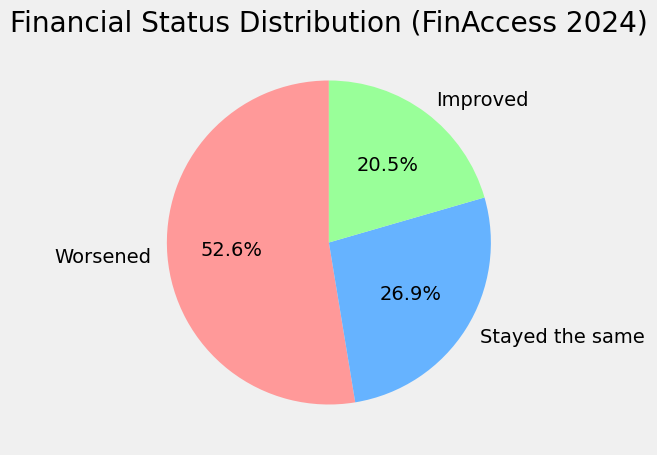

In [158]:
import matplotlib.pyplot as plt
# Target distribution counts numbers
target_counts = df['financial_status'].value_counts()
with plt.style.context(plt.style.available[8]):
    plt.figure(figsize=(15, 5))
    # Plotting the pie chart
    plt.pie(
        target_counts,
        labels=target_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=['#ff9999','#66b3ff','#99ff99']  # optional color scheme
            )
    plt.title('Financial Status Distribution (FinAccess 2024)')
    plt.show()

In [159]:
from sklearn.preprocessing import LabelEncoder
target_encoder = {
    'Worsened': 0, 
    'Stayed the same': 1, 
    'Improved': 2
}
df[target_variable+"_encoded"] = df[target_variable].map(target_encoder)

The labels are ordinal 2 < 1 < 1

##### Binary Features

In [160]:
# Instantiating the binary columns 
binary_columns = ["Savings_formal","Savings_informal","Loan_formal",
               "Loan_informal","defaulted","formal_service_use",
               "mobile_money_access","mobile_ownership_1","experienced_shock",
               "nfhi_11","nfhi_12","nfhi_13","accessto_13k_1month","not_difficult","has_disability","Sex", 'location_type'
]
# Label encoding each column
binary_encoders = {}
for col in binary_columns:
    le = LabelEncoder()
    df[col+"_encoded"] = le.fit_transform(df[col])
    binary_encoders[col] = le
binary_encoders

{'Savings_formal': LabelEncoder(),
 'Savings_informal': LabelEncoder(),
 'Loan_formal': LabelEncoder(),
 'Loan_informal': LabelEncoder(),
 'defaulted': LabelEncoder(),
 'formal_service_use': LabelEncoder(),
 'mobile_money_access': LabelEncoder(),
 'mobile_ownership_1': LabelEncoder(),
 'experienced_shock': LabelEncoder(),
 'nfhi_11': LabelEncoder(),
 'nfhi_12': LabelEncoder(),
 'nfhi_13': LabelEncoder(),
 'accessto_13k_1month': LabelEncoder(),
 'not_difficult': LabelEncoder(),
 'has_disability': LabelEncoder(),
 'Sex': LabelEncoder(),
 'location_type': LabelEncoder()}

For the above binary features we could have one-hot encoded but that introduces the curse of dimensionality 

We can use label encoding then later on we can aggregate them with other features to reduce dimensions and combine the signal into one feature

#####  Ordinal Features

Age

In [161]:
# First Grouping based on target mean 
age_group_map = {
    "16-17": "Younger",
    "18-25": "Younger",
    "26-35": "Middle",
    "36-45": "Middle",
    "46-55": "Older",
    "Above 55": "Older"
}
df["Age_group"] = df["Age"].map(age_group_map)
# Encoding Age group
age_group_ord_map = {
    "Younger": 0,
    "Middle": 1,
    "Older": 2
}

df["Age_group_encoded"] = df["Age_group"].map(age_group_ord_map)

Education

In [162]:
df.groupby("education_level")["financial_status_encoded"].mean()

education_level
95                                                     0.500000
"Don't know (DO NOT READ OUT)"                         1.000000
"None "                                                0.544094
"Other (Specify) "                                     0.000000
"Primary completed"                                    0.602074
"Refused to Answer (DO NOT READ OUT)"                  0.333333
"Secondary completed "                                 0.734500
"Some primary "                                        0.576789
"Some secondary"                                       0.754302
"University completed "                                0.945344
Completed technical training after secondary school    0.814215
Some technical training after secondary school         0.906188
Some university                                        0.973988
Name: financial_status_encoded, dtype: float64

From the above we can use the mean in relation to the target to reduce the number of unique values

Unique values with closer means are grouped together for a better signal

In [163]:
# Checking the unique values 
df['education_level'].unique()

array(['Completed technical training after secondary school', '"None "',
       '"Primary completed"', '"Some secondary"',
       'Some technical training after secondary school',
       '"Secondary completed "', '"Some primary "',
       '"University completed "', '"Other (Specify) "', 'Some university',
       95, '"Refused to Answer (DO NOT READ OUT)"',
       '"Don\'t know (DO NOT READ OUT)"'], dtype=object)

In [164]:
# Mapping the unique values with close to similar means together
education_group_map = {
    '"Refused to Answer (DO NOT READ OUT)"': "Low",
    '"Other (Specify) "': "Low",
    95: "Low",
    "\"None \"": "Low",
    "\"Some primary \"": "Low",
    "\"Primary completed\"": "Low",

    "\"Secondary completed \"": "Medium",
    "\"Some secondary\"": "Medium",

    "Completed technical training after secondary school": "High",
    "Some technical training after secondary school": "High",
    "\"University completed \"": "High",
    "Some university": "High",
    "\"Don't know (DO NOT READ OUT)\"": "High"
}
df["education_group"] = df["education_level"].map(education_group_map)
# Encoding the groups into numbers : 2 < 1 < 0
education_group_ord_map = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}
df["education_group_encoded"] = df["education_group"].map(education_group_ord_map)

Financial Literacy Score

In [165]:
# Getting the mean for each unique value 
df.groupby("fl_score")["financial_status_encoded"].mean()

fl_score
All correct     0.713667
None correct    0.744741
One correct     0.648440
Two correct     0.653644
Name: financial_status_encoded, dtype: float64

In [166]:
# Grouping unique values with similar means togeter
fl_group_map = {
    "None correct": "High",
    "One correct": "Low",   
    "Two correct": "Low",   
    "All correct": "Medium"  
}
df["fl_group"] = df["fl_score"].map(fl_group_map)
# Encoding the financial literacy  ordinally: 2 < 1 < 0
fl_group_ord_map = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}
df["fl_group_encoded"] = df["fl_group"].map(fl_group_ord_map)

In [167]:
# Defining the nominal variables - they have high cardinality 
nominal_variables = ["county","marital_status","barriers_bank","barriers_mobile_money"]
df[nominal_variables].nunique()

county                   47
marital_status            6
barriers_bank            10
barriers_mobile_money    10
dtype: int64

For this variables we will use the group means for the unique values to map them ordinally 


Marital Status

In [168]:
# Group means for more informed logical decison 
df.groupby("marital_status")["financial_status_encoded"].mean()

marital_status
Divorced/separated                    0.529783
Don't know   (DO NOT READ OUT)        0.400000
Married/Living with partner           0.644789
Refused to Answer(DO NOT READ OUT)    0.000000
Single/Never Married                  0.853899
Widowed                               0.500672
Name: financial_status_encoded, dtype: float64

In [169]:
# Mapping similar means together 
marital_group_map = {
    "Refused to Answer(DO NOT READ OUT)": "Unknown",
    "Don't know   (DO NOT READ OUT)": "Unknown",
    "Divorced/separated": "Separated/Widowed",
    "Widowed": "Separated/Widowed",
    "Married/Living with partner": "Married/Partnered",
    "Single/Never Married": "Single"
}

df["marital_group"] = df["marital_status"].map(marital_group_map)
# Ordinal encoding the marital status with respect to the financial status: 3 < 2 < 1 < 0
marital_group_ord_map = {
    "Unknown": 0,
    "Separated/Widowed": 1,
    "Married/Partnered": 2,
    "Single": 3
}
df["marital_group_encoded"] = df["marital_group"].map(marital_group_ord_map)

Barriers Bank

In [170]:
# Obtaining the group means
df.groupby("barriers_bank")["financial_status_encoded"].mean()

barriers_bank
Access                     0.639234
Affordability              0.577217
Awareness                  0.713243
Charges/Product pricing    0.703704
Eligibility                0.929953
Not Applicable             0.762644
Other                      0.972222
Relevance/Suitability      0.836066
Service quality            0.444444
Trust                      0.719298
Name: financial_status_encoded, dtype: float64

In [171]:
# Mapping the similar groups together
barriers_group_map = {
    "Service quality": "Low",
    "Affordability": "Low",
    "Access": "Medium",
    "Charges/Product pricing": "Medium",
    "Awareness": "Medium",
    "Trust": "Medium",
    "Relevance/Suitability": "High",
    "Not Applicable": "High",
    "Eligibility": "High",
    "Other": "High"
}

df["barriers_bank_group"] = df["barriers_bank"].map(barriers_group_map)
# Ordinal Encoding
barriers_group_ord_map = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}
df["barriers_bank_group_encoded"] = df["barriers_bank_group"].map(barriers_group_ord_map)

Barriers Mobile Money

In [172]:
# Group means 
df.groupby("barriers_mobile_money")["financial_status_encoded"].mean()

barriers_mobile_money
0                        0.668252
Affordability            0.601382
Awareness                0.694444
Eligibility              0.925703
Line blocked             0.662338
Other                    0.622222
Phone ownership          0.663887
Relevance/Suitability    0.758065
Service quality          0.666667
Trust                    0.888889
Name: financial_status_encoded, dtype: float64

In [173]:
# Mapping the simila groups together
barriers_mobile_group_map = {
    "Affordability": "Low",
    "Other": "Low",
    "Line blocked": "Medium",
    "Phone ownership": "Medium",
    "Service quality": "Medium",
    0: "Medium",  # Access
    "Awareness": "Medium",
    "Relevance/Suitability": "High",
    "Trust": "High",
    "Eligibility": "High"
}
df["barriers_mobile_group"] = df["barriers_mobile_money"].map(barriers_mobile_group_map)
# Ordinal Encoding
barriers_mobile_group_ord_map = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}
df["barriers_mobile_group_encoded"] = df["barriers_mobile_group"].map(barriers_mobile_group_ord_map)

County

In [174]:
# Group means
df.groupby("county")["financial_status_encoded"].mean()

county
Baringo            0.960836
Bomet              1.001887
Bungoma            0.773256
Busia              0.614035
Elgeyo-Marakwet    0.870892
Embu               0.575314
Garissa            0.401961
Homabay            0.408163
Isiolo             0.746711
Kajiado            0.657767
Kakamega           0.790349
Kericho            0.774336
Kiambu             0.695009
Kilifi             0.686792
Kirinyaga          0.690945
Kisii              0.560636
Kisumu             0.353612
Kitui              0.898383
Kwale              0.496021
Laikipia           0.763926
Lamu               0.492248
Machakos           0.829365
Makueni            0.762115
Mandera            0.901554
Marsabit           0.449864
Meru               0.544741
Migori             0.777778
Mombasa            0.696262
Murang'a           0.629845
Nairobi City       0.768489
Nakuru             0.590909
Nandi              0.858947
Narok              0.714286
Nyamira            0.585921
Nyandarua          0.536131
Nyeri        

In [175]:
# Mapping the similar counties together 
county_group_map = {
    # High
    "Bomet": "High", "Baringo": "High", "Wajir": "High", "West Pokot": "High",
    "Mandera": "High", "Kitui": "High", "Elgeyo-Marakwet": "High",
    "Nandi": "High", "Machakos": "High",
    # Medium
    "Kakamega": "Medium", "Migori": "Medium", "Bungoma": "Medium",
    "Kericho": "Medium", "Nairobi City": "Medium", "Isiolo": "Medium",
    "Uasin Gishu": "Medium", "Narok": "Medium", "Mombasa": "Medium",
    "Kiambu": "Medium", "Kilifi": "Medium", "Kirinyaga": "Medium",
    "Taita-Taveta": "Medium", "Trans Nzoia": "Medium", "Tharaka-Nithi": "Medium",
    "Makueni": "Medium", "Laikipia": "Medium", "Kajiado": "Medium",
    "Samburu": "Medium",
    # Low
    "Murang'a": "Low", "Nyeri": "Low", "Busia": "Low", "Vihiga": "Low",
    "Nakuru": "Low", "Nyamira": "Low", "Kisii": "Low", "Meru": "Low",
    "Nyandarua": "Low", "Kwale": "Low", "Lamu": "Low", "Marsabit": "Low",
    "Siaya": "Low", "Garissa": "Low", "Homabay": "Low", "Kisumu": "Low",
    "Turkana": "Low", "Tana River": "Low", "Embu": "Low"
}
df["county_group"] = df["county"].map(county_group_map)
# Ordinal Encoding 
county_group_ord_map = {"Low": 0, "Medium": 1, "High": 2}
df["county_group_encoded"] = df["county_group"].map(county_group_ord_map)


#### Numerical Variables

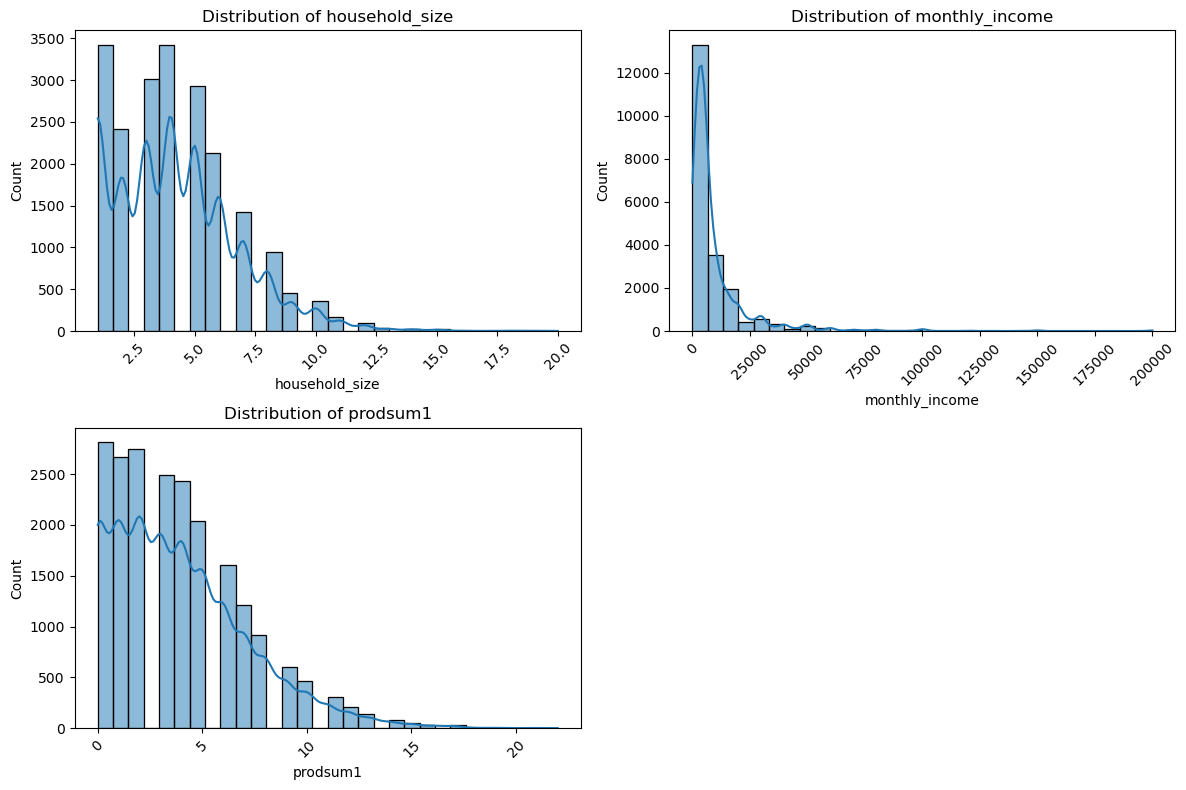

In [176]:
import seaborn as sns
import matplotlib.pyplot as plt
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12,8))
axes = axes.flatten()
# Remove unused axes which logically is = 1
for i in range(len(numerical_columns), len(axes)):
    fig.delaxes(axes[i])
for i, col in enumerate(numerical_columns):
    sns.histplot(df[col], kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    # Rotating the axis labels - so that they fit into the plot
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Monthly Income

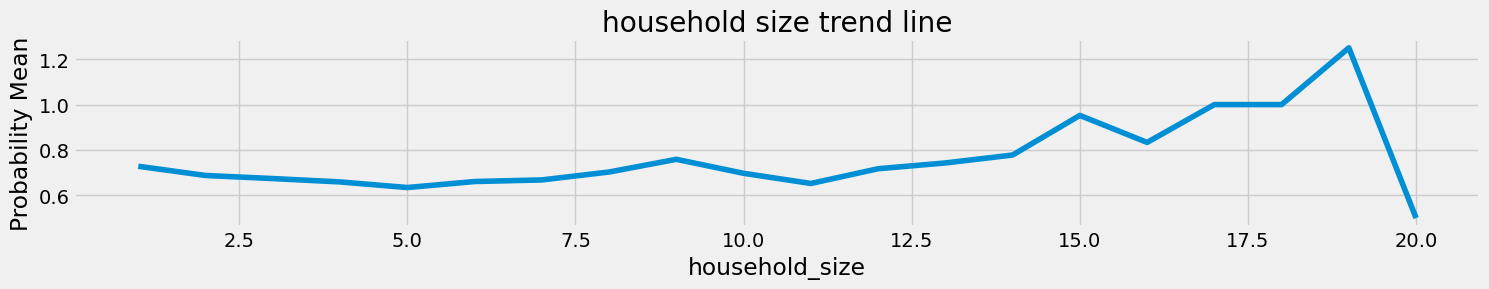

In [177]:
# Checking if there is a trend
with plt.style.context(plt.style.available[8]):
    plt.figure(figsize=(15, 3))
    df.groupby("household_size")["financial_status_encoded"].mean().plot()
    plt.title('household size trend line')
    plt.ylabel('Probability Mean')
plt.tight_layout()
plt.show()

From the above trend we can see that as household size increases 

It increases the probability for financial stability

In [178]:
# Investigating the household size relationship to the target
df[df["household_size"] == 20]["financial_status_encoded"].value_counts()

financial_status_encoded
1    1
0    1
Name: count, dtype: int64

In [179]:
# Dropping this row because it is a noise factor disrupting the trend
df = df[df["household_size"] != 20]

From the trend plot we can see that the general direction is upwards 

This is disrupted by household size= 20 which is also one value 

This is a clear indication of an outlier 

In [180]:
# Checking the value counts
df['household_size'].value_counts()

household_size
1     3425
4     3416
3     3013
5     2936
2     2414
6     2124
7     1422
8      946
9      452
10     360
11     164
12      92
13      35
14      27
15      21
16       6
18       5
19       4
17       2
Name: count, dtype: int64

From the distribution plot earlier most of the household sizes = 1 - 15 

We are going to clip the values beyond 15 not drop - meaning the maximum size = 15

In [181]:
# Clipping household size
df["household_size"] = df["household_size"].clip(upper=15)

In [182]:
# Grouping the household sizes : as per the group means in relation to the financial status
df["household_group"] = pd.cut(
    df["household_size"],
    bins=[0,3,6,10,15],
    labels=["Small","Medium","Large","Very Large"]
).astype(object)
# Ordinal encoding 
df["household_group_encoded"] = df["household_group"].map(
    {"Small":0,"Medium":1,"Large":2,"Very Large":3}
)

products used

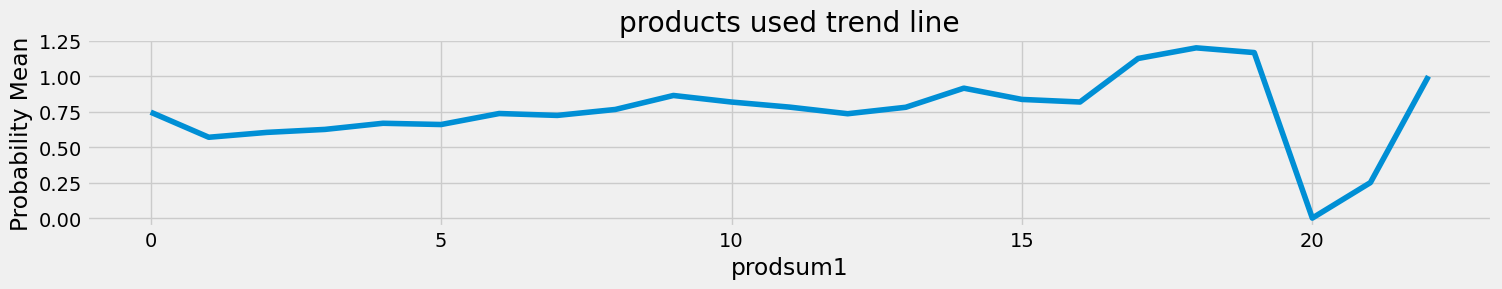

In [183]:
# Checking if there is a trend
with plt.style.context(plt.style.available[8]):
    plt.figure(figsize=(15, 3))
    df.groupby("prodsum1")["financial_status_encoded"].mean().plot()
    plt.title('products used trend line')
    plt.ylabel('Probability Mean')
plt.tight_layout()
plt.show()

From the above trend we can see that as products used increases 

It increases the probability for financial stability

In [184]:
df['prodsum1'].value_counts()

prodsum1
0     2817
2     2750
1     2663
3     2488
4     2430
5     2041
6     1605
7     1216
8      913
9      604
10     467
11     303
12     208
13     137
14      83
15      55
16      33
17      32
19       6
18       5
21       4
22       2
20       2
Name: count, dtype: int64

Values 20 and 21 violate the trend assumption plus they are extremas and also few in count 

This is a clear indication of an outlier 

In [185]:
# Dropping 20 and 21 they are too high and go against the trend
df = df[~df["prodsum1"].isin([20,21])]
# Clipping the high values -  this is to reduce the spread 
df["prodsum1_clipped"] = df["prodsum1"].clip(upper=15)

In [186]:
# Grouping the products used in relation to the trend plot 
df["prodsum1_group"] = pd.cut(
    df["prodsum1_clipped"],
    bins=[-1,2,5,10,15],
    labels=["Very Low","Low","Medium","High"]
).astype(object)
# Ordinal Encoding the groups
df["prodsum1_group_encoded"] = df["prodsum1_group"].map(
    {"Very Low":0,"Low":1,"Medium":2,"High":3}
)

Monthly Income

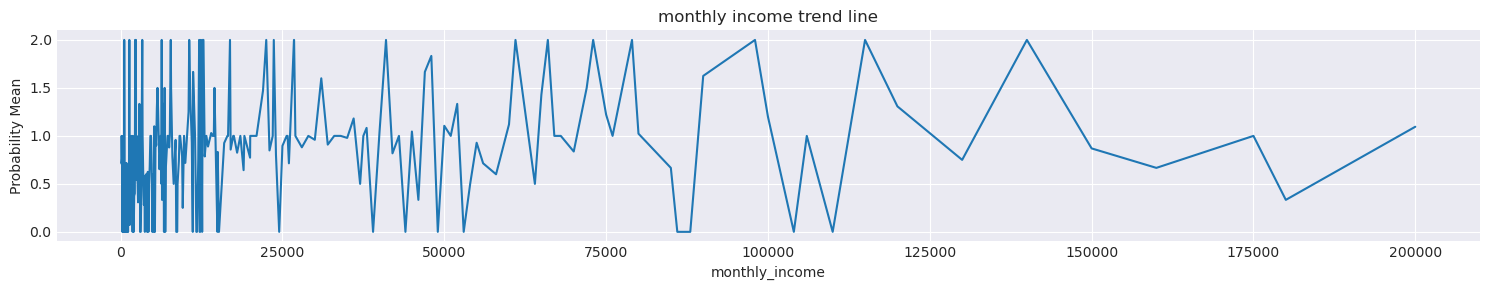

In [187]:
# Checking if there is a trend
with plt.style.context(plt.style.available[17]):
    plt.figure(figsize=(15, 3))
    df.groupby("monthly_income")["financial_status_encoded"].mean().plot()
    plt.title('monthly income trend line')
    plt.ylabel('Probability Mean')
plt.tight_layout()
plt.show()

From the above trend plot the general direction is not that visible 

This indicates monthly income varies from household to household

This can be logically interpreted by the fact that the level of success is not the same in all households

In [188]:
# Clipping the extremem incomes to the income at the 95th percentile
upper = df["monthly_income"].quantile(0.95)
df["monthly_income_clipped"] = df["monthly_income"].clip(upper=upper)

In [189]:
# Getting the summary statistics for monthly income 
df['monthly_income'].describe()

count     20858.000000
mean       9698.082366
std       15420.137875
min         100.000000
25%        2500.000000
50%        5000.000000
75%       10000.000000
max      200000.000000
Name: monthly_income, dtype: float64

In [190]:
# Grouping monthly income into bands
df["income_group"] = pd.cut(
    df["monthly_income"],
    bins=[0, 2500, 5000, 10000, 50000, df["monthly_income"].max()],
    labels=["Low","Lower-Mid","Upper-Mid","High","Very High"]
)
# Ordinal encoding the income bands
df["income_group_encoded"] = df["income_group"].map({
    "Low":0, "Lower-Mid":1, "Upper-Mid":2, "High":3, "Very High":4
})

In [191]:
# Reducing Skewness - Scaling the monthly income - using yeo-johnson
# The values are to sparse as seen in the summary statistics
from sklearn.preprocessing import PowerTransformer, StandardScaler
income_pt = PowerTransformer(method='yeo-johnson')
transformed_income_pt = income_pt.fit_transform(df[["monthly_income_clipped"]])
# Standard scale after transformation - so that the variable assumes a normal distribution(mean=0, std=1)
# Monthly income might hold a strong signal 
# Sparsity makes generalization hard - standardization might boost generalization
income_scaler = StandardScaler()
income_scaled = income_scaler.fit_transform(transformed_income_pt)
df["monthly_income_transformed"] = income_scaled

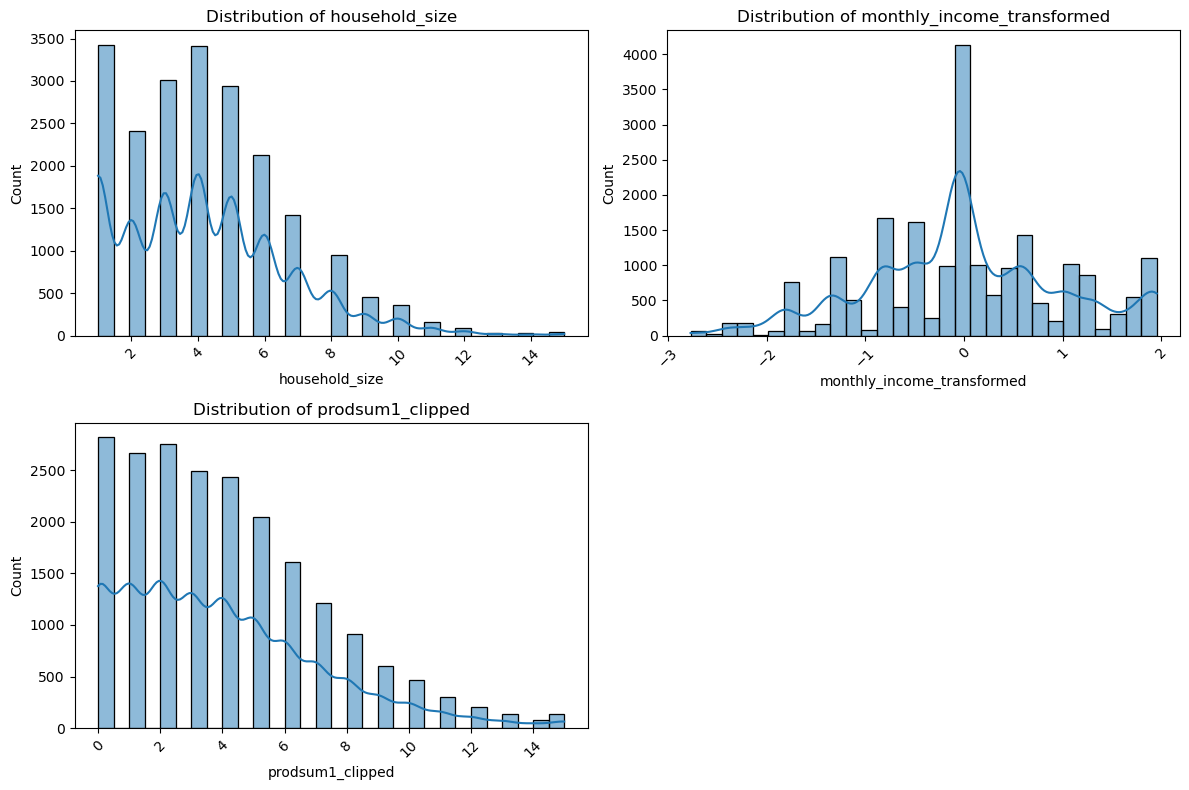

In [192]:
# Plotting the distributions for the newly investigated numerical columns
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12,8))
axes = axes.flatten()
# Remove unused axes if fewer numerical columns
for i in range(len(numerical_columns), len(axes)):
    fig.delaxes(axes[i])
# Histogram for each variable 
for i, col in enumerate(['household_size', "monthly_income_transformed", "prodsum1_clipped"]):
    sns.histplot(df[col], kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    # Rotate the x-axis labels - so that they fit in the plot 
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

From the above:

1. Monthly income - normal distribution - its values were so sparse
2. Products used - the range was not that big plus the trend showed a clear signal(preserved)
3. This was the same for household size(same as products used)

#### Feature Interactions

In [193]:
# Creating a unified saving score
df['savings_score'] = (
    (df['Savings_formal'] == 'Usage').astype(int) +
    (df['Savings_informal'] == 'Usage').astype(int)
)
df['savings_score'].unique()

array([0, 2, 1])

Checking the intensity of saving on a scale of 1-3

In [194]:
# Checking for the signal in savings score
pd.DataFrame(df.groupby("savings_score")["financial_status_encoded"].mean())

,financial_status_encoded
savings_score,
0,0.602245
1,0.738184
2,0.762879


The is no clear signal but in combination with another feature it might boost signal 

We are planning to condense information but also not be vague in our instances

If we immediately dispose of this then we might use data uniqueness

In [195]:
# Creating a unified loan score 
df['loan_score'] = (
    (df['Loan_formal'] == 'Usage').astype(int) +
    (df['Loan_informal'] == 'Usage').astype(int)
)
df['loan_score'].unique()

array([1, 0, 2])

Checking the intensity of saving on a scale of 1-3

In [196]:
pd.DataFrame(df.groupby("loan_score")["financial_status_encoded"].mean())

,financial_status_encoded
loan_score,
0,0.720396
1,0.677220
2,0.601145


The is no clear signal but in combination with another feature it might boost signal 

We are planning to condense information but also not be vague in our instances

If we immediately dispose of this then we might use data uniqueness

In [197]:
df['financial_inclusion'] = (
    (df['Savings_formal'] == 'Usage').astype(int) +
    (df['Savings_informal'] == 'Usage').astype(int) +
    (df['Loan_formal'] == 'Usage').astype(int) +
    (df['Loan_informal'] == 'Usage').astype(int) +
    (df['mobile_money_access'] == 'Yes').astype(int) +
    (df['formal_service_use'] == 'Usage').astype(int) +
    (df['mobile_ownership_1_encoded'] == 'Yes').astype(int)+
    (df['accessto_13k_1month_encoded'] == 'Yes').astype(int) +
    (df['not_difficult_encoded'] == "Yes").astype(int) +
    (df['nfhi_11_encoded'] == "Yes").astype(int) +
    (df['nfhi_12_encoded'] == "Yes").astype(int) +
    (df['nfhi_13_encoded'] == "Yes").astype(int)
)

Financial Inclusion - participation in the financial system

In [198]:
pd.DataFrame(df.groupby("financial_inclusion")["financial_status_encoded"].mean())

,financial_status_encoded
financial_inclusion,
0,0.713333
1,0.650655
2,0.624444
3,0.671621
4,0.708214
5,0.688561
6,0.667308


We can see means are roughly the same

But we cannot drop this now there might be noise affecting the means

In [199]:
# Unified financial literacy score
df['financial_literacy_score'] = (
    (df['nfhi_11'] == 'Yes').astype(int) +
    (df['nfhi_12'] == 'Yes').astype(int) +
    (df['nfhi_13'] == 'Yes').astype(int)
)
df['financial_literacy_score'].unique()

array([3, 1, 0, 2])

Checking how financially sound each instance 

In [200]:
pd.DataFrame(df.groupby("financial_literacy_score")["financial_status_encoded"].mean())

,financial_status_encoded
financial_literacy_score,
0,0.407733
1,0.535939
2,0.683737
3,0.918370


There is clear separation here where the higher the financial literacy score the higher the chances of financial stability

In [201]:
# Calculating the expected income per person in a household
df['income_per_person'] = (
    df['monthly_income_transformed'] /
    df['household_size']
)

Getting each person's contribution to the household economy

In [202]:
# This helps distinguish wealthy households that experienced shocks from poor households that experienced shocks.
df['shock_income'] = (
    (df['experienced_shock'] == 'Yes').astype(int)
    * df['monthly_income_transformed']
)

Checking if there is a difference:
    
     1. High earner - experiences shock  
     2. Low earner - experiences  shock  
For instance accident then new unplanned bills 

In [203]:
# Accesss to financial services interaction with financial literacy score
df['access_literacy'] = (
    df['financial_literacy_score']
    * df['financial_inclusion']
)

Condensing information further

In [204]:
pd.DataFrame(df.groupby("access_literacy")["financial_status_encoded"].mean())

,financial_status_encoded
access_literacy,
0,0.529904
1,0.597156
2,0.541494
3,0.508475
4,0.564701
5,0.555071
6,0.743162
8,0.725622
9,0.940878


In [205]:
# Unified State Variable
df["resilience_index"] = (
    df["financial_literacy_score"] +
    df["financial_inclusion"] +
    df["access_literacy"] +
    (df['accessto_13k_1month_encoded'] == 'Yes').astype(int)+
    (df['not_difficult_encoded'] == "Yes").astype(int) 
)

In [206]:
pd.DataFrame(df.groupby("resilience_index")["financial_status_encoded"].mean())

,financial_status_encoded
resilience_index,
0,0.260870
1,0.500879
2,0.561000
3,0.627370
4,0.431579
5,0.515931
6,0.502110
7,0.508475
8,0.536810


In [207]:
df["vulnerability_score"] = (
    (df["Sex_encoded"] == 1).astype(int) +   # if female or disadvantaged gender
    (df["has_disability_encoded"] == 1).astype(int) +
    (df["location_type_encoded"] == 1).astype(int)   # e.g. rural/remote
)

## 4. Defining the feature Variables 

In [208]:
# Checking the all the columns together 
print(df.columns)

Index(['county', 'location_type', 'Sex', 'Age', 'household_size',
       'education_level', 'marital_status', 'monthly_income', 'Savings_formal',
       'Savings_informal', 'Loan_formal', 'Loan_informal', 'defaulted',
       'formal_service_use', 'mobile_money_access', 'barriers_mobile_money',
       'mobile_ownership_1', 'experienced_shock', 'nfhi_11', 'nfhi_12',
       'nfhi_13', 'accessto_13k_1month', 'not_difficult', 'financial_status',
       'fl_score', 'prodsum1', 'barriers_bank', 'has_disability',
       'financial_status_encoded', 'Savings_formal_encoded',
       'Savings_informal_encoded', 'Loan_formal_encoded',
       'Loan_informal_encoded', 'defaulted_encoded',
       'formal_service_use_encoded', 'mobile_money_access_encoded',
       'mobile_ownership_1_encoded', 'experienced_shock_encoded',
       'nfhi_11_encoded', 'nfhi_12_encoded', 'nfhi_13_encoded',
       'accessto_13k_1month_encoded', 'not_difficult_encoded',
       'has_disability_encoded', 'Sex_encoded', 'locatio

There some features that might be redundant because they were used to generate feature interaction variables

In [209]:
# Creating the modelling dataset
drop_columns = ['Savings_formal','Savings_informal','Loan_formal','Loan_informal',
                'defaulted','formal_service_use','mobile_money_access','mobile_ownership_1',
                'experienced_shock','nfhi_11','nfhi_12','nfhi_13','accessto_13k_1month',
                'not_difficult','has_disability','Sex','location_type','county','marital_status', 
                'barriers_mobile_money','financial_status','fl_score','barriers_bank','Age_group',
                'fl_group','education_group','marital_group','barriers_mobile_group','barriers_bank_group',
                'county_group', 'Age', 'education_level', 'financial_status', 'monthly_income', 'income_group', 
                'prodsum1_group', 'household_group', 'Savings_formal_encoded','Savings_informal_encoded', 
                'Loan_formal_encoded','Loan_informal_encoded', 'nfhi_11_encoded', 'nfhi_12_encoded', 'nfhi_13_encoded',
                'household_size', 'household_group_encoded', 'formal_service_use_encoded', 'defaulted_encoded', 
                'mobile_money_access_encoded', 'mobile_ownership_1_encoded', 'Sex_encoded', 'has_disability_encoded', 'location_type_encoded',
                "savings_score","loan_score", "financial_inclusion", "experienced_shock_encoded","prodsum1",
                "prodsum1_group_encoded","fl_group_encoded","education_group_encoded",  "vulnerability_score"
]
df2 = df.copy().drop(columns=drop_columns, axis=1)

In [210]:
# Checking the variables we will use for modelling
df2.columns

Index(['financial_status_encoded', 'accessto_13k_1month_encoded',
       'not_difficult_encoded', 'Age_group_encoded', 'marital_group_encoded',
       'barriers_bank_group_encoded', 'barriers_mobile_group_encoded',
       'county_group_encoded', 'prodsum1_clipped', 'monthly_income_clipped',
       'income_group_encoded', 'monthly_income_transformed',
       'financial_literacy_score', 'income_per_person', 'shock_income',
       'access_literacy', 'resilience_index'],
      dtype='object')

In [211]:
from sklearn.feature_selection import mutual_info_classif
# Splitting the features and target
X = df2.drop(columns=["financial_status"], errors="ignore")  
y = df["financial_status"] 
# Calculatingn the mutual information a variable has with regards to target
mi_scores = mutual_info_classif(X, y, discrete_features='auto', random_state=42)
mi_df = pd.DataFrame({
    "Feature": X.columns,
    "MutualInfo": mi_scores
}).sort_values(by="MutualInfo", ascending=False)
print(mi_df)

                          Feature  MutualInfo
0        financial_status_encoded    1.017128
12       financial_literacy_score    0.031538
16               resilience_index    0.025022
15                access_literacy    0.023683
1     accessto_13k_1month_encoded    0.019780
9          monthly_income_clipped    0.019489
7            county_group_encoded    0.019479
3               Age_group_encoded    0.019336
11     monthly_income_transformed    0.015159
13              income_per_person    0.014236
10           income_group_encoded    0.014059
4           marital_group_encoded    0.010268
2           not_difficult_encoded    0.008667
5     barriers_bank_group_encoded    0.007489
8                prodsum1_clipped    0.007078
14                   shock_income    0.005935
6   barriers_mobile_group_encoded    0.005381


Most of the above features have very little information scores

And as per the preprocessing most features above are combinations of other features we should expect the opposite

In [212]:
# Checking the length of the original dataframe and the new dataframe match 
len(df2), len(df)

(20858, 20858)

## 5. Data Evaluation 

Checking if the current data by itself can generalize and produce good results

The model choices are as follows:

     1. Logistic Regression - Linear based model
     2. Random Forest Classifier - Tree/Ensemble model 

This models will give a good baseline for how our data explains the target 

In [213]:
# Splitting the data into training and testing splits
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
X = df2.drop(columns = ['financial_status_encoded'], axis=1)
y = df2['financial_status_encoded']
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [214]:
# Logistic Regression baseline
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

print("Logistic Regression Report:\n", classification_report(y_test, y_pred_lr))
# For multiclass problems, specify the multi_class argument
print("ROC-AUC (LogReg):", 
      roc_auc_score(y_test, log_reg.predict_proba(X_test),
                    multi_class='ovr'))  # or 'ovo'

# Random Forest baseline
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
probs_rf = rf.predict_proba(X_test) 
# Printing the results
print("\nRandom Forest Report:\n", classification_report(y_test, y_pred_rf))
print("ROC-AUC (RandomForest):", 
      roc_auc_score(y_test, probs_rf, multi_class='ovr'))  # or 'ovo'
#Feature importance from Random Forest
feat_importances = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)
print("\nTop Features:\n", feat_importances.head(10))

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.68      0.54      0.60      2194
           1       0.35      0.33      0.34      1122
           2       0.33      0.52      0.40       856

    accuracy                           0.48      4172
   macro avg       0.45      0.46      0.45      4172
weighted avg       0.52      0.48      0.49      4172

ROC-AUC (LogReg): 0.6576832853579323

Random Forest Report:
               precision    recall  f1-score   support

           0       0.67      0.64      0.65      2194
           1       0.39      0.34      0.36      1122
           2       0.34      0.44      0.38       856

    accuracy                           0.52      4172
   macro avg       0.47      0.47      0.47      4172
weighted avg       0.53      0.52      0.52      4172

ROC-AUC (RandomForest): 0.665891353370561

Top Features:
                        Feature  Importance
12           income_per_person    0.142844
7   

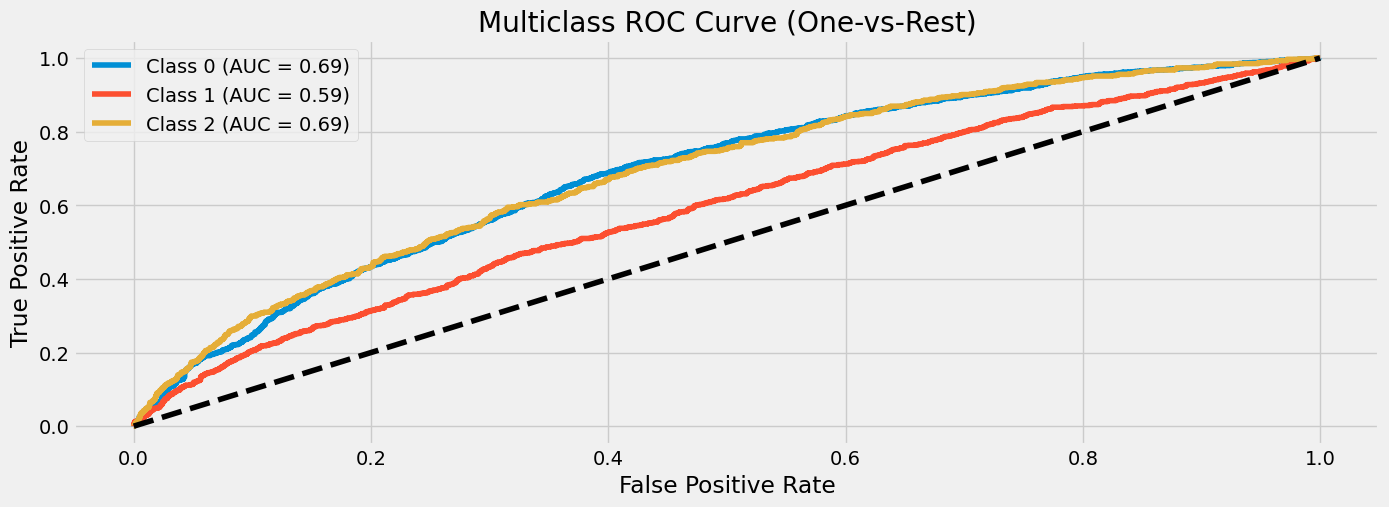

In [215]:
from sklearn.metrics import roc_curve, auc
# Probabilities for each class
y_score = log_reg.predict_proba(X_test)
# Binarize the labels for one-vs-rest
from sklearn.preprocessing import label_binarize
classes = log_reg.classes_
y_test_bin = label_binarize(y_test, classes=classes)
with plt.style.context(plt.style.available[8]):
    # Plot ROC curve for each class
    plt.figure(figsize=(15,5))
    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"Class {cls} (AUC = {roc_auc:.2f})")
    # Chance line
    plt.plot([0,1],[0,1],'k--')
    plt.title("Multiclass ROC Curve (One-vs-Rest)")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()


From the above results our model is basically guessing same case as a coin toss

This is a strong indication the predictors are not able to clearly separate 

The model sees a worsened case and it is similar to a stayed  the same case 


## 6. Dimensionality Reduction
----------------------------------------------
This will help me see how different values behave in relation to the target class

##### Principal Component Analysis 

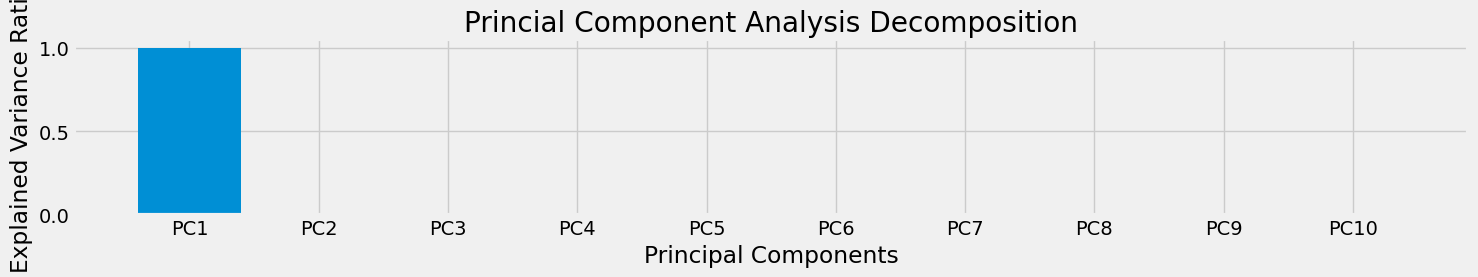

In [216]:
from sklearn.decomposition import PCA
# Separate features and target
X = df2.drop(columns='financial_status_encoded')
y = df2['financial_status_encoded']
# Fitting the pca on the feature set
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X)
# Explained variance ratios
explained_var = pca.explained_variance_ratio_
# Display as a DataFrame for clarity
pca_summary = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(len(explained_var))],
    "Explained Variance Ratio": explained_var
})
with plt.style.context(plt.style.available[8]):
    plt.figure(figsize=(15, 3))
    plt.bar(pca_summary['Principal Component'], pca_summary['Explained Variance Ratio'])
    plt.title('Princial Component Analysis Decomposition')
    plt.xlabel('Principal Components')
    plt.ylabel('Explained Variance Ratio')
    plt.tight_layout()
    plt.show()

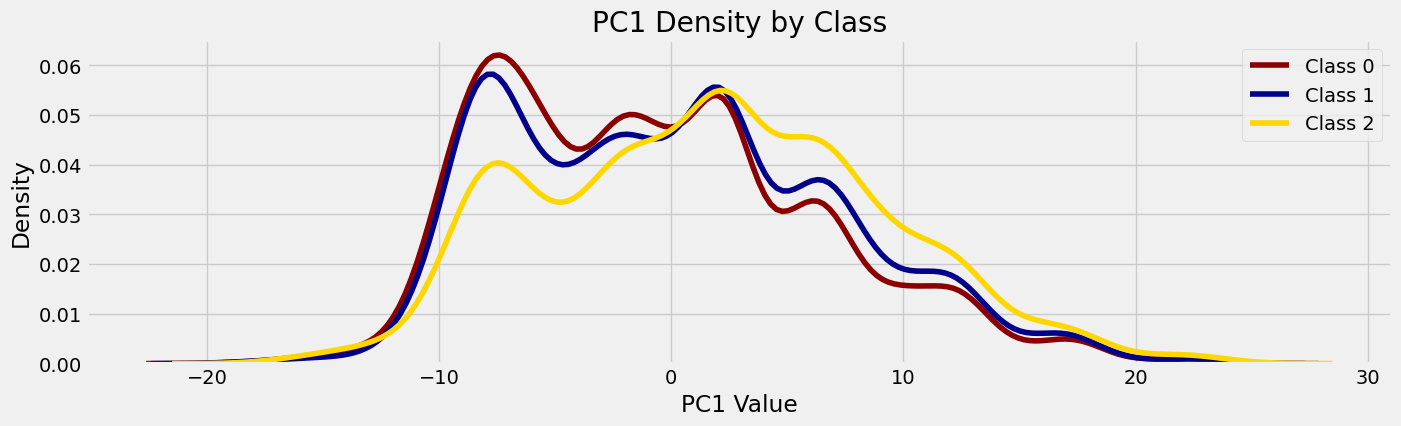

In [217]:
# Analyzing distribution difference between the different target classes 
# This will help show if pca captured the differences between the classes as per the data
pc1 = X_pca[:, 1]
with plt.style.context(plt.style.available[8]):
    plt.figure(figsize=(15, 4))
    sns.kdeplot(pc1[y==0], color="darkred", label="Class 0")
    sns.kdeplot(pc1[y==1], color="darkblue", label="Class 1")
    sns.kdeplot(pc1[y==2], color="gold", label="Class 2")
    plt.title("PC1 Density by Class")
    plt.xlabel("PC1 Value")
    plt.legend()
    plt.show()


PCA Decomposition Summary

- PC1 explains ~100% of the variance.
- PC2–PC10 explain almost 0%.

$$Interpretation$$
The dataset currently is essentially one‑dimensional — all features are highly correlated or redundant.

PCA found only one meaningful direction (PC1) that captures nearly all variability.

Because the remaining components carry negligible variance, PCA cannot separate classes — there’s no orthogonal structure left to exploit.

PCA shows data is dominated by one latent factor — that’s why everything collapsed onto PC1.

##### Clustering 
----------------------------
Check if natural grouping exists 

If the each cluster dominates its own cluster

This will show that the data can be separated into the target classes

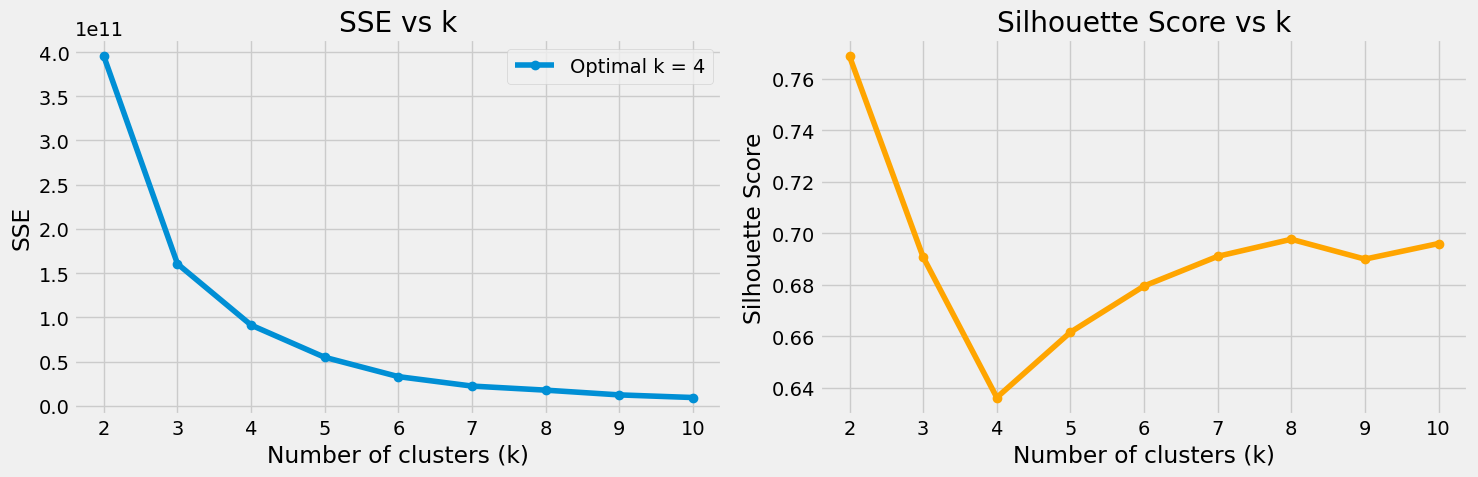

In [218]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator
# Storage for metrics
k_range = range(2, 11)
SSE = []
scores = []
# Evaluate different cluster sizes
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42).fit(X)  # use your dataset here
    SSE.append(km.inertia_)  # inertia = SSE
    scores.append(silhouette_score(X, km.labels_))
# Find optimal k using KneeLocator
optimal_k = KneeLocator(k_range, SSE, curve='convex', direction='decreasing').elbow
# Plot results
# SSE plot
with plt.style.context(plt.style.available[8]):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    axes[0].plot(k_range, SSE, marker='o', label=f'Optimal k = {optimal_k}')
    axes[0].set_title("SSE vs k")
    axes[0].set_xlabel("Number of clusters (k)")
    axes[0].set_ylabel("SSE")
    axes[0].legend()
    # Silhouette score plot
    axes[1].plot(k_range, scores, marker='o', color='orange', label=f'Optimal k = {optimal_k}')
    axes[1].set_title("Silhouette Score vs k")
    axes[1].set_xlabel("Number of clusters (k)")
    axes[1].set_ylabel("Silhouette Score")
    plt.tight_layout()
    plt.show()

In [219]:
# Labelling the data 
km = KMeans(n_clusters=4, random_state=42).fit(X)
df2['labels'] = km.predict(X)
# Assuming df2 has both 'labels' (from KMeans) and 'target' (your original class column)
cluster_distribution = pd.crosstab(df2['labels'], df2['financial_status_encoded'])
print(cluster_distribution)

financial_status_encoded     0     1     2
labels                                    
0                         4435  2266  1630
1                          618   389   650
2                         1313   734   826
3                         4604  2218  1175


In [220]:
# Normalize by row to get proportions per cluster
cluster_distribution_pct = cluster_distribution.div(cluster_distribution.sum(axis=1), axis=0)
print(cluster_distribution_pct.round(2))

financial_status_encoded     0     1     2
labels                                    
0                         0.53  0.27  0.20
1                         0.37  0.23  0.39
2                         0.46  0.26  0.29
3                         0.58  0.28  0.15


The clusters are very mixed meaning it could not separate the data adequately 

For instance in cluster 0 all target classes are represented

## 7. Collapsing data into binary classification
----------------------------------------------
There are three target classes:

     1. Improved
     2. Stayed the same 
     3. Worsened
Improved and worsened might have clear separation on their own 

But when we put Stayed the same - the data points overlap with the other 2 classes hurting the ability of model to segement feature properties into their specific target classes

We can do this:   

     stayed the same , worsened = same class - not stable financial status
     improved same class - meaning stable financial status

In [221]:
# Collapsing the current class into binary 
# O-worsened 1=stayed the same 2 = improved --> 0 not stable else 1 stable
df2.drop(columns=['labels'], axis=1, inplace=True)
df2['binary_target'] = np.where(df2['financial_status_encoded']==2, 1, 0)

In [222]:
df2['binary_target'].value_counts()

binary_target
0    16577
1     4281
Name: count, dtype: int64

The distribution is skewed with the improved class having approx. 4X less values

##### Linear Discriminant Analysis
-----------------------------------------------------
Checking if distributions show class separation

If they are intertwined means we can separate the data

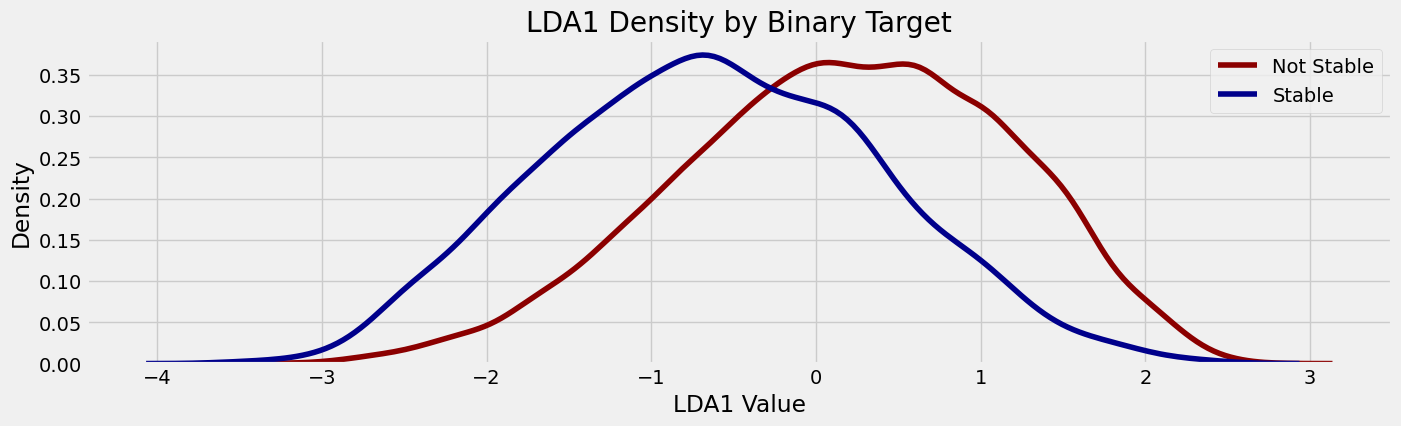

In [223]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import matplotlib.pyplot as plt
import seaborn as sns
# Use your binary target
X = df2.drop(columns=['binary_target','financial_status_encoded'], axis=1)
y = df2['binary_target']
# Fit LDA
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X, y)
# Density plot of LDA1 per class
with plt.style.context(plt.style.available[8]):
    plt.figure(figsize=(15, 4))
    sns.kdeplot(X_lda[y==0].ravel(), color="darkred", label="Not Stable")
    sns.kdeplot(X_lda[y==1].ravel(), color="darkblue", label="Stable")
    plt.title("LDA1 Density by Binary Target")
    plt.xlabel("LDA1 Value")
    plt.legend()
    plt.show()


LDA statistically identifies directions that maximize class separation.  

In this plot, the “Stable” and “Not Stable” groups have distinct peaks along LDA1, showing that LDA successfully found a linear combination of features that minimizes within-class variance and maximizes

between-class variance —  hence clear differentiation between the two financial stability states.

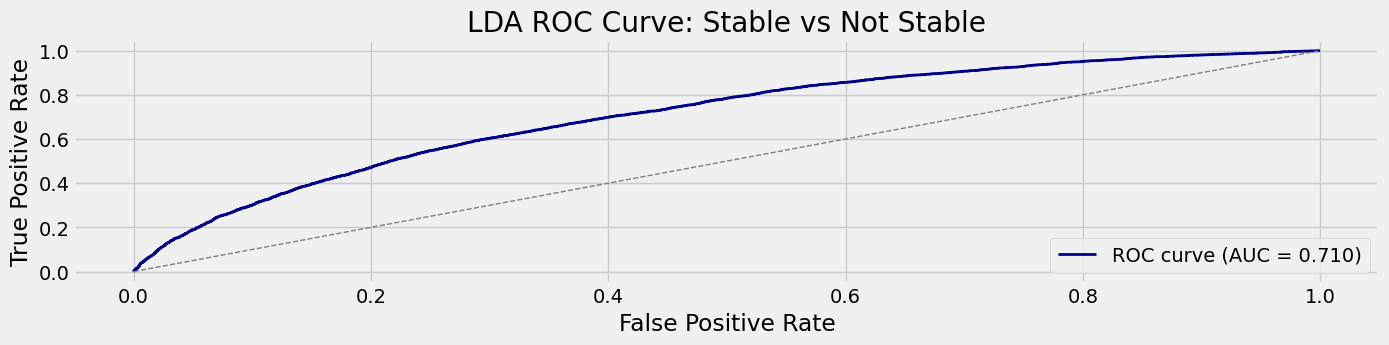

In [224]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
# Fit LDA on your binary target
lda = LinearDiscriminantAnalysis()
lda.fit(X, y)
# Get predicted probabilities for the positive class (Stable)
y_prob = lda.predict_proba(X)[:, 1]
# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y, y_prob)
roc_auc = auc(fpr, tpr)
# Plot ROC curve
with plt.style.context(plt.style.available[8]):
    plt.figure(figsize=(15, 3))
    plt.plot(fpr, tpr, color='darkblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0,1], [0,1], color='gray', lw=1, linestyle='--')
    plt.title('LDA ROC Curve: Stable vs Not Stable')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.show()



The ROC curve shows how well the LDA model distinguishes between “Stable” and “Not Stable.”  
An AUC of 0.71 means the model performs moderately well — better than random guessing (AUC = 0.5)  
but not perfect (AUC = 1.0). It indicates that LDA captures meaningful separation between classes,  
though there’s still overlap and room for improvement in discriminative power.


<Figure size 1500x300 with 0 Axes>

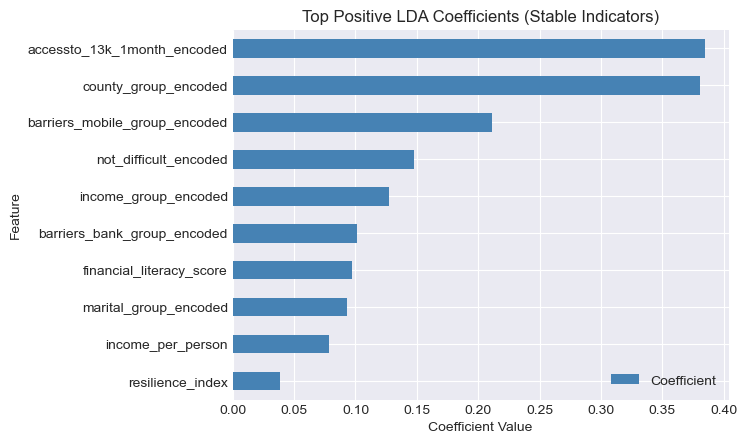

<Figure size 1500x200 with 0 Axes>

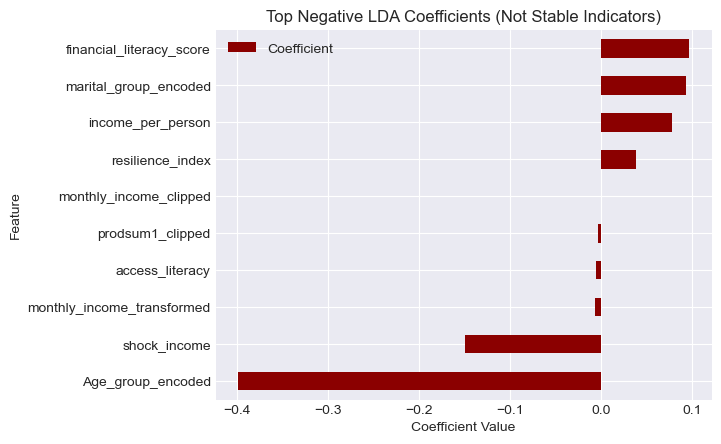

In [225]:
# Get LDA coefficients
coef = lda.coef_[0]
features = X.columns
# Create a DataFrame for clarity
lda_weights = pd.DataFrame({
    'Feature': features,
    'Coefficient': coef
}).sort_values(by='Coefficient', ascending=False)
# Plot top and bottom contributors
with plt.style.context(plt.style.available[17]):
    plt.figure(figsize=(15, 3))
    lda_weights.head(10).plot(kind='barh', x='Feature', y='Coefficient', color='steelblue')
    plt.title('Top Positive LDA Coefficients (Stable Indicators)')
    plt.xlabel('Coefficient Value')
    plt.gca().invert_yaxis()
    plt.show()
    plt.figure(figsize=(15, 2))
    lda_weights.tail(10).plot(kind='barh', x='Feature', y='Coefficient', color='darkred')
    plt.title('Top Negative LDA Coefficients (Not Stable Indicators)')
    plt.xlabel('Coefficient Value')
    plt.gca().invert_yaxis()
    plt.show()

#### Computing the decision Boundary 

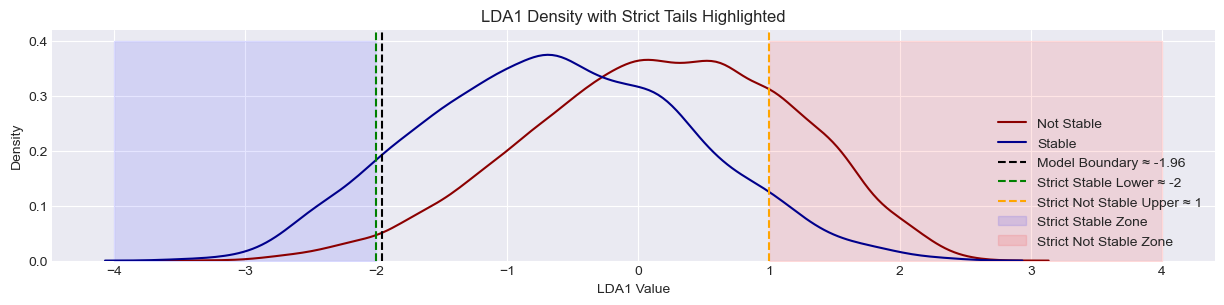

In [226]:
# Fit LDA
lda = LinearDiscriminantAnalysis()
lda.fit(X, y)
X_lda = lda.transform(X)
# Predicted probabilities for the positive class (Stable)
y_prob = lda.predict_proba(X)[:, 1]
# Compute the model’s internal boundary (probability = 0.5)
boundary = np.mean(X_lda[(y_prob > 0.49) & (y_prob < 0.51)])
# Define strict boundaries
lower_boundary = -2
upper_boundary = 1
# Plot densities with strict zones
with plt.style.context(plt.style.available[17]):
    plt.figure(figsize=(15, 3))
    sns.kdeplot(X_lda[y==0].ravel(), color="darkred", label="Not Stable")
    sns.kdeplot(X_lda[y==1].ravel(), color="darkblue", label="Stable")
    # Add boundaries
    plt.axvline(boundary, color="black", linestyle="--", label=f"Model Boundary ≈ {boundary:.2f}")
    plt.axvline(lower_boundary, color="green", linestyle="--", label=f"Strict Stable Lower ≈ {lower_boundary}")
    plt.axvline(upper_boundary, color="orange", linestyle="--", label=f"Strict Not Stable Upper ≈ {upper_boundary}")
    # Highlight tails
    plt.fill_betweenx([0, 0.4], -4, lower_boundary, color="blue", alpha=0.1, label="Strict Stable Zone")
    plt.fill_betweenx([0, 0.4], upper_boundary, 4, color="red", alpha=0.1, label="Strict Not Stable Zone")
    plt.title("LDA1 Density with Strict Tails Highlighted")
    plt.xlabel("LDA1 Value")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

Explanation Summary

- The blue curve (Stable) and red curve (Not Stable) represent LDA1 density distributions.
- You defined strict cut‑off zones:
  • Strict Stable Zone → LDA1 < –2  
  • Strict Not Stable Zone → LDA1 > 1  
- The green dashed line (≈ –1.96) marks the model’s natural boundary between classes.
- The shaded tails highlight regions with minimal overlap — the “pure” signals.
- We will use these tails to extract clean subsets for modeling, ensuring high‑confidence samples
  while excluding the ambiguous middle region.


**Stayed the same** is not a well-separated class but a transitional state between **improved** and **worsened**, and most prediction error originates from this overlap region.

#### Now removing Outliers


Values that violate assumptions

In [227]:
# LDA projection
lda_values = X_lda.ravel()
# Define strict boundaries
lower_boundary = -2
upper_boundary = 1
# Defining the classification zones - depending on the boundaries
df2['classification_zone'] = np.where(
    lda_values < lower_boundary, 'Strict Stable',
    np.where(lda_values > upper_boundary, 'Strict Not Stable', 'Overlap')
)
# Checking the value counts for the deifferent regions
print(df2['classification_zone'].value_counts())

classification_zone
Overlap              16212
Strict Not Stable     3935
Strict Stable          711
Name: count, dtype: int64


#### Investigating if the labels match our assumptions

In [228]:
# Investigating the value counts in relation to the target 
for value in ['Strict Stable', 'Strict Not Stable', 'Overlap']:
    print(f"============={value}================\n")
    value_count = df2[df2['classification_zone']==value]['financial_status_encoded'].value_counts()
    print(value_count)

=============Strict Stable================

financial_status_encoded
2    390
1    167
0    154
Name: count, dtype: int64
=============Strict Not Stable================

financial_status_encoded
0    2845
1     842
2     248
Name: count, dtype: int64
=============Overlap================

financial_status_encoded
0    7971
1    4598
2    3643
Name: count, dtype: int64


##### Encoding Map
2 = improved 1 = stayed the same 0 = worsened - financial status encoded

1 = improved 0 = stayed the same / worsened
##### Interpretation
Strict Stable:
   
    Majority are 2 (Improved) → 390 cases, with fewer in 1 (167) and 0 (154).

Strict Not Stable: 
    
    Dominated by 0 (Worsened) → 2,845 cases, with smaller pockets of 1 (842) and 2 (248).

Overlap: 
    
    Mixed spread → 7,971 worsened, 4,598 same level, 3,643 improved.
    This is expected because distributions were overlapping distorting signals

#### Removing outliers 
--------------------------------------------------
This is basically segraging the data from the tails and the middle region in the lda plot

The data from the tails are the cleanest and the data from the middle region are overlapping values between the 'worsened' and 'improved' target classes so we will ignore for now 

In [229]:
# Segregating the stable zone dataframes
strict_stable_df = df2[df2['classification_zone'] == 'Strict Stable']
strict_not_stable_df = df2[df2['classification_zone'] == 'Strict Not Stable']
# Getting outliers inside the strict zones
# stable means the value should only be = 2
stable_df_clean = strict_stable_df[strict_stable_df['financial_status_encoded'] == 2]
# stable means the value should only be = 0 
notstable_df_clean = strict_not_stable_df[strict_not_stable_df['financial_status_encoded'] == 0]
print("Stable data:", stable_df_clean.shape)
print("Not Stable data:", notstable_df_clean.shape)

Stable data: (390, 19)
Not Stable data: (2845, 19)


Testing if the data separation between the:

       stable - which means they improved
       not stable - which means they worsened 
exists

In [230]:
# Combine the cleaned strict datasets
strict_df_clean = pd.concat([stable_df_clean, notstable_df_clean])

# Features and target
X_strict = strict_df_clean.drop(columns=['financial_status_encoded', 'classification_zone', 'binary_target'])
y_strict = strict_df_clean['financial_status_encoded']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_strict, y_strict, test_size=0.3, random_state=42, stratify=y_strict
)

# Simple model: Logistic Regression
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       854
           2       1.00      1.00      1.00       117

    accuracy                           1.00       971
   macro avg       1.00      1.00      1.00       971
weighted avg       1.00      1.00      1.00       971



From the above results we can see the features clearly separate the data into the worsened class and the improved class

The features now have a clear signal and this means we can use this data to make meaningful insights

Clustering to verify target class separation

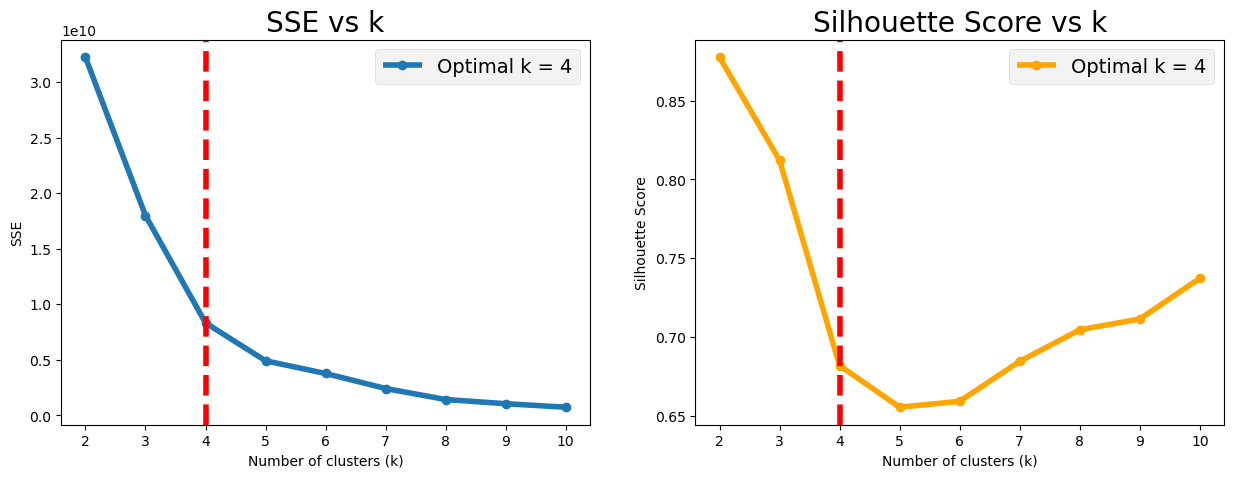

In [231]:
# To further clarify separation
# Storage for metrics
k_range = range(2, 11)
SSE_strict = []
scores_strict = []
# Evaluate different cluster sizes
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42).fit(X_strict) 
    SSE_strict.append(km.inertia_)  # inertia = SSE
    scores_strict.append(silhouette_score(X_strict, km.labels_))
# Find optimal k using KneeLocator
optimal_k_strict = KneeLocator(k_range, SSE_strict, curve='convex', direction='decreasing').elbow
# Plot results
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# SSE plot
with plt.style.context(plt.style.available[8]):
    axes[0].plot(k_range, SSE_strict, marker='o', label=f'Optimal k = {optimal_k_strict}')
    axes[0].axvline(optimal_k_strict, linestyle="--", color='red')
    axes[0].set_title("SSE vs k")
    axes[0].set_xlabel("Number of clusters (k)")
    axes[0].set_ylabel("SSE")
    axes[0].legend()
    # Silhouette score plot
    axes[1].plot(k_range, scores_strict, marker='o', color='orange', label=f'Optimal k = {optimal_k_strict}')
    axes[1].axvline(optimal_k, linestyle="--", color='red')
    axes[1].set_title("Silhouette Score vs k")
    axes[1].set_xlabel("Number of clusters (k)")
    axes[1].set_ylabel("Silhouette Score")
    axes[1].legend()
    plt.show()

In [246]:
# Labelling the data 
km_strict = KMeans(n_clusters=optimal_k_strict, random_state=42).fit(X_strict)
strict_df_clean['labels'] = km_strict.predict(X_strict)
cluster_distribution_strict = pd.crosstab(strict_df_clean['labels'], strict_df_clean['financial_status_encoded'])
pd.DataFrame(cluster_distribution_strict)

financial_status_encoded,0,2
labels,,
0,1750,0
1,0,255
2,29,103
3,1066,32


From the above we can see that natural separation exists 

Cluster Results (Strict Dataset)

Cluster 0 → Purely Not Stable
- 1709 samples, all class 0
- Very clean separation, no contamination

Cluster 1 → Purely Stable
- 281 samples, almost all class 2
- Only 2 misfits, otherwise pure

Cluster 2 → Mixed Cluster
- 102 class 0 and 101 class 2
- Balanced split, represents borderline cases

Cluster 3 → Mostly Not Stable
- 1032 class 0 and 8 class 2
- Strong lean toward class 0, but with small contamination


#### Investigating the overlapping region

In [233]:
# Re-Checking the unique values 
df2['classification_zone'].unique()

array(['Overlap', 'Strict Not Stable', 'Strict Stable'], dtype=object)

We will take data from the overlapping region in the lda plot

The middle region expectation is that that is the staying the same region so the financial status  label = 1 

In [234]:
# Segregating the overlap zone into a dataframe
strict_overlap_df = df2[df2['classification_zone'] == 'Overlap']
# overlap means the value should only be = 1
overlap_df_clean = strict_overlap_df[strict_overlap_df['financial_status_encoded'] == 1]
print("Overlap data = ", overlap_df_clean.shape)

Overlap data =  (4598, 19)


In [235]:
# Getting the strict stable & not stable 
# The should also show clear separation as per clustering 
# The strict clusters = 0, 1, 3 there is a mixture in cluster 2
strict_df_clean_clear_signal = strict_df_clean[strict_df_clean['labels'] != 2]
strict_df_clean_clear_signal.shape

(3032, 20)

In [236]:
# Getting the value counts for the strict df clean that has a clear signal
pd.crosstab(strict_df_clean_clear_signal['labels'], strict_df_clean_clear_signal['financial_status_encoded'])

financial_status_encoded,0,2
labels,,
0,1709,0
1,2,281
3,1032,8


So we have 3032 rows between the two classes worsened and improved

Now we can concatenate with the overlap dataframe and model and see the result

In [237]:
# This one has kmeans labels
len(strict_df_clean_clear_signal.columns)

20

In [238]:
# This one doesnt have kmeans labels yet
len(overlap_df_clean.columns)

19

In [239]:
# Combining  strict df with stable/not stable with clear signal and overlap dataset
combined_df_overlap_strict = pd.concat([strict_df_clean_clear_signal.drop(columns='labels', axis=1), overlap_df_clean], axis=0, ignore_index=True)
pd.DataFrame(combined_df_overlap_strict['classification_zone'].value_counts())

,count
classification_zone,
Overlap,4598
Strict Not Stable,2743
Strict Stable,289


In [240]:
# Checking the length of the current dataframe state
len(combined_df_overlap_strict)

7630

In [241]:
# Getting the features to fit into the cluster dataframe 
X_strict_overlap = combined_df_overlap_strict.drop(columns=['financial_status_encoded', 'binary_target', 'classification_zone'], axis=1)

Clustering the clean stable + non stable data with noisy overlap data

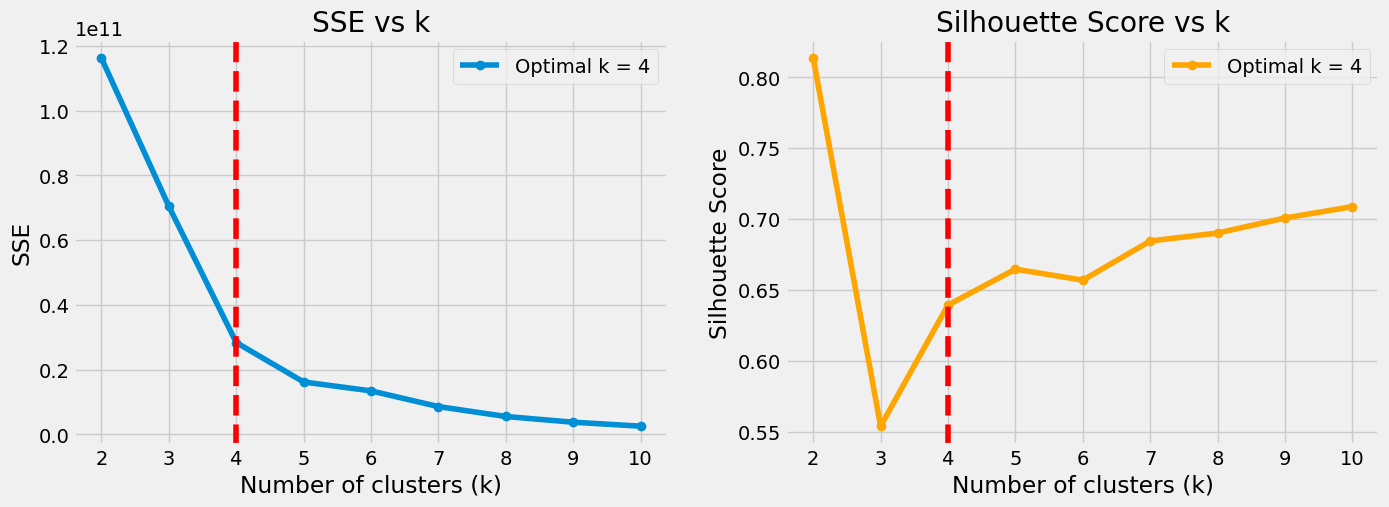

In [242]:
# To further clarify separation
# Storage for metrics
k_range = range(2, 11)
SSE_strict_overlap = []
scores_strict_overlap = []
# Evaluate different cluster sizes
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42).fit(X_strict_overlap) 
    SSE_strict_overlap.append(km.inertia_)  # inertia = SSE
    scores_strict_overlap.append(silhouette_score(X_strict_overlap, km.labels_))
# Find optimal k using KneeLocator
optimal_k_strict_overlap = KneeLocator(k_range, SSE_strict_overlap, curve='convex', direction='decreasing').elbow
# Plot results
with plt.style.context(plt.style.available[8]):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    # SSE plot
    axes[0].plot(k_range, SSE_strict_overlap, marker='o', label=f'Optimal k = {optimal_k_strict_overlap}')
    axes[0].axvline(optimal_k_strict_overlap, linestyle="--", color='red')
    axes[0].set_title("SSE vs k")
    axes[0].set_xlabel("Number of clusters (k)")
    axes[0].set_ylabel("SSE")
    axes[0].legend()
    # Silhouette score plot
    axes[1].plot(k_range, scores_strict_overlap, marker='o', color='orange', label=f'Optimal k = {optimal_k_strict_overlap}')
    axes[1].axvline(optimal_k_strict_overlap, linestyle="--", color='red')
    axes[1].set_title("Silhouette Score vs k")
    axes[1].set_xlabel("Number of clusters (k)")
    axes[1].set_ylabel("Silhouette Score")
    axes[1].legend()
    plt.show()

In [247]:
# Labelling the data 
km_strict_overlap = KMeans(n_clusters=optimal_k_strict_overlap, random_state=42).fit(X_strict_overlap)
combined_df_overlap_strict['labels'] = km_strict_overlap.predict(X_strict_overlap)
cluster_distribution_strict_overlap = pd.crosstab(combined_df_overlap_strict['labels'], combined_df_overlap_strict['financial_status_encoded'])
pd.DataFrame(cluster_distribution_strict_overlap)

financial_status_encoded,0,1,2
labels,,,
0,1754,1453,0
1,0,282,256
2,987,2188,8
3,2,675,25


Cluster 0 - dominated by worsened and improved 
cluster 1 - the number of stayed the same and improved are same
cluster 2 this is highly dominated by stayed the same but the number of values that are worsened are significant
cluster 3 - dominated by stayed the same datapoints

The best choice lies between cluster 2 and 3 
**Decision**: We choose cluster 3 since it has a lot of data points for the model 

In [295]:
# Extracting pure overlapping data - set 1
clean_overlap_df = combined_df_overlap_strict[combined_df_overlap_strict['labels'].isin([2, 3])]
len(clean_overlap_df)

3885

## 8. Final Modelling

#### Creating the combine strict overlap clean df with clear signal

In [296]:
strict_overlap_df_clean_clear_signal = pd.concat(
    [clean_overlap_df.drop(columns='labels', axis=1), strict_df_clean_clear_signal.drop(columns='labels', axis=1)], 
    axis=0 , 
    ignore_index=True
)
len(strict_overlap_df_clean_clear_signal) == len(strict_df_clean_clear_signal) + len(clean_overlap_df)

True

In [297]:
len(strict_overlap_df_clean_clear_signal)

6917

#### Building final Model
---------------------------
Building the model with clean data with clear signals

 Weighted F1-Score = 0.9787546268424172
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1120
           1       0.98      0.96      0.97       859
           2       0.94      0.94      0.94        97

    accuracy                           0.98      2076
   macro avg       0.97      0.97      0.97      2076
weighted avg       0.98      0.98      0.98      2076



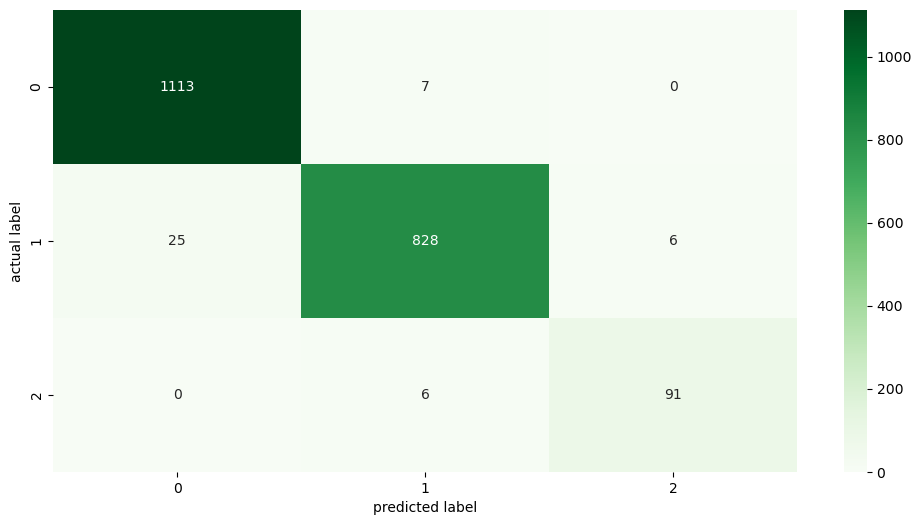

In [298]:
import warnings
from sklearn.metrics import f1_score
# Features and target
X_strict_overlap = strict_overlap_df_clean_clear_signal.drop(columns=['financial_status_encoded', 'classification_zone', 'binary_target'])
y_strict_overlap = strict_overlap_df_clean_clear_signal['financial_status_encoded']
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_strict_overlap, y_strict_overlap, test_size=0.3, random_state=42, stratify=y_strict_overlap
)
# Simple model: Logistic Regression
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    # Predictions
    y_pred = model.predict(X_test)
    # Evaluation
    # Weighted f1 score
    weighted_f1_score = f1_score(y_test, y_pred, average='weighted')
    print(f'\033[91m Weighted F1-Score\033[92m = {weighted_f1_score}\033[0m')
    # Classification report
    print(classification_report(y_test, y_pred))
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(12, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
    plt.xlabel('predicted label')
    plt.ylabel('actual label')
    plt.show()

In [299]:
# Obtaining the intercept(constant[c]) and coefficients
coefs = model.coef_
intercepts = model.intercept_
# Extracting the X feature names 
feature_names = X_train.columns
for idx, (intercept, coef) in enumerate(zip(intercepts, coefs)):
    terms = " + ".join([f"{round(c,4)}*{f}" for c, f in zip(coef, feature_names)])
    print(f"Logit(Class {idx}) = {round(intercept,4)} + {terms}")

Logit(Class 0) = 1.7949 + -2.5139*accessto_13k_1month_encoded + -1.3109*not_difficult_encoded + 4.1907*Age_group_encoded + 0.1888*marital_group_encoded + -0.8721*barriers_bank_group_encoded + 0.4267*barriers_mobile_group_encoded + -3.106*county_group_encoded + -0.0359*prodsum1_clipped + -0.0001*monthly_income_clipped + 0.1877*income_group_encoded + -1.9873*monthly_income_transformed + -0.5384*financial_literacy_score + -0.8663*income_per_person + -0.6187*shock_income + -0.8822*access_literacy + 0.298*resilience_index
Logit(Class 1) = -0.4914 + 1.9693*accessto_13k_1month_encoded + 0.6473*not_difficult_encoded + -0.4874*Age_group_encoded + 0.1997*marital_group_encoded + -0.0936*barriers_bank_group_encoded + 0.6132*barriers_mobile_group_encoded + 1.1625*county_group_encoded + 0.1433*prodsum1_clipped + -0.0003*monthly_income_clipped + 1.4924*income_group_encoded + 1.7381*monthly_income_transformed + 0.7021*financial_literacy_score + 0.2612*income_per_person + 0.8186*shock_income + -0.8441*

Class 0 equation: Large positive weight on Age_group_encoded (+4.93) means age grouping strongly pushes predictions toward Class 0. Negative weights on accessto_13k_1month_encoded and county_group_encoded pull predictions away.

Class 1 equation: Positive weights on accessto_13k_1month_encoded, income_group_encoded, and financial_literacy_score show that financial access and literacy push predictions toward Class 1

Class 2 equation: Positive weight on access_literacy (+1.51) means literacy access strongly drives predictions toward Class 2, while negative weights on Age_group_encoded and marital_group_encoded push away.

In [300]:
# Confirming the model was trained with the right data 
print('Clean data with clear signal   = ', len(strict_overlap_df_clean_clear_signal))
print('Length of the training dataset = ', len(X_train))
print('Length of the testing dataset  = ', len(X_test))

Clean data with clear signal   =  6917
Length of the training dataset =  4841
Length of the testing dataset  =  2076


## 9. Explainable AI - shapey values

#### 1. Intializing the Explainer

In [301]:
# Building the linear explainer object
import shap
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    # Build the mask with all len(X_train) samples
    explainer_masker = shap.maskers.Independent(X_train, max_samples=len(X_train))
    # Initializing the explainer
    explainer = shap.Explainer(model, masker=explainer_masker)
    # Computing the shap values for the X_test
    shap_values = explainer(X_test)

In [302]:
# Checking the shape of the shap values
shap_values.shape, X_test.shape

((2076, 16, 3), (2076, 16))

The 3 is because - target has 3 classes so we can see why the model predicted each class's probability

#### 2. Global Feature Importance

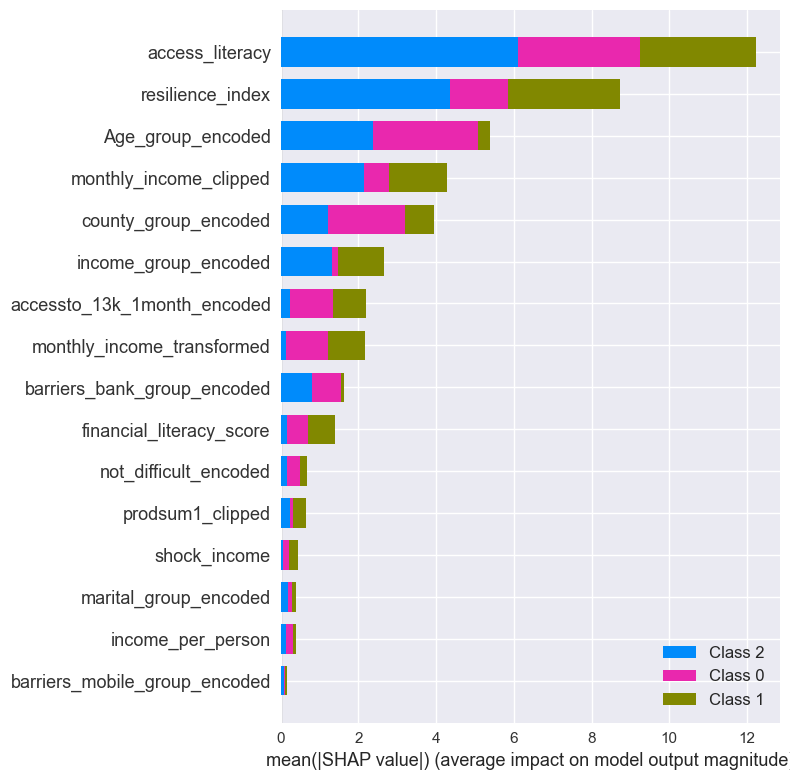

In [303]:
# Plotting overall feature importance for the model - per class (global explanation)
with plt.style.context(plt.style.available[12]):
    plt.figure(figsize=(15, 3))
    shap.summary_plot(shap_values, X_test)
    plt.show()

#####  SHAP Summary Plot Interpretation

##### 1️ Overall Insight
The model’s predictions are **strongly influenced by socioeconomic and literacy-related features**.  
`access_literacy` dominates across all classes, indicating that access to literacy resources consistently drives classification outcomes.

---

##### 2️ Class-Specific Patterns
- **Class 0 (olive green):** Heavily influenced by `access_literacy` and `county_group_encoded`, suggesting that **regional and literacy access factors** define this group.  
- **Class 1 (blue):** Shows strong dependence on `access_literacy` and `Age_group_encoded`, implying that **demographic and educational access** shape predictions.  
- **Class 2 (pink):** Influenced by `resilience_index` and `monthly_income_clipped`, indicating that **financial stability and resilience** are key differentiators.

---

##### 3️ Feature Interactions
Income-related features such as `monthly_income_clipped`, `monthly_income_transformed`, and `income_group_encoded` appear multiple times, showing that **economic capacity interacts with literacy and resilience dimensions**.

---

##### 4️ Lower-Impact Features
`barriers_mobile_group_encoded`, `not_difficult_encoded`, and `income_per_person` have minimal SHAP values, meaning they contribute little to the model’s decision boundaries.

---

##### 5️ Interpretation Summary
The model primarily distinguishes classes based on **literacy access, age, resilience, and income**.  
These features collectively reflect **socioeconomic empowerment and access disparities**, which are central to the classification logic.

---

#####  Recommendation
Focus policy or intervention strategies on **enhancing literacy access and financial resilience**, as these are the most influential predictors of inclusion outcomes.  
Improving regional literacy programs and income stability could significantly shift the model’s predicted outcomes toward positive inclusion.


#### Examining corelation  to the target variable
-----------------------------------------

In [304]:
correlations = {}
for meth in ['pearson', 'kendall', 'spearman']:
    correlation = strict_overlap_df_clean_clear_signal.drop(
        columns=['classification_zone', 'binary_target'], 
        axis=1
    ).corr(
        method=meth
    )['financial_status_encoded']
    correlations[meth] = correlation
correlation_dataframe = pd.DataFrame(correlations)
correlation_dataframe

,pearson,kendall,spearman
financial_status_encoded,1.000000,1.000000,1.000000
accessto_13k_1month_encoded,0.579647,0.563087,0.574349
not_difficult_encoded,0.428818,0.421045,0.429466
Age_group_encoded,-0.493133,-0.470699,-0.504223
marital_group_encoded,0.400427,0.384163,0.411834
barriers_bank_group_encoded,0.391428,0.348047,0.367976
barriers_mobile_group_encoded,0.121340,0.126531,0.130406
county_group_encoded,0.550330,0.510165,0.539730
prodsum1_clipped,0.350036,0.225264,0.265387
monthly_income_clipped,0.719445,0.599096,0.685593


#### ANOVA - checking variables differ across the differented classed
---------------------

#####  Hypothesis Statement 

For monthly income and literacy scores:

- **Null Hypothesis (H₀):**  
  The mean value of the variable is equal across all classes. 

- **Alternative Hypothesis (H₁):**  
  At least one class has a significantly different mean value compared to the others.

---

##### Reason for this Analysis 
- This hypothesis framework allows to test whether **class membership is associated with differences in the variable’s distribution**.  
- If H₀ is rejected (p-value < 0.05), it means the variable contributes to distinguishing classes, supporting the SHAP findings.  
- If H₀ is not rejected, the variable may not be a strong differentiator, even if SHAP shows some importance.


In [305]:
import pandas as pd
from scipy.stats import f_oneway, kruskal

# Income and literact score
groups_income = [strict_df_clean_clear_signal.loc[strict_df_clean_clear_signal['financial_status_encoded']==c, 'monthly_income_clipped'] for c in strict_df_clean_clear_signal['financial_status_encoded'].unique()]
groups_literacy = [strict_df_clean_clear_signal.loc[strict_df_clean_clear_signal['financial_status_encoded']==c, 'access_literacy'] for c in strict_df_clean_clear_signal['financial_status_encoded'].unique()]
# Analysis of Variance
anova_income = f_oneway(*groups_income)
anova_literacy = f_oneway(*groups_literacy)
# Printing the result
for i, p_value in enumerate([anova_income.pvalue, anova_literacy.pvalue]):
    if i == 0:
        if p_value < 0.05:
            print(f'As per ANOVA p-value = {p_value} for monthly income, the means between different classes differ significant\nThis means that monthly income contributes to final decison of the model\n\n')
            continue
    if p_value < 0.05:
        print(f'As per ANOVA p-value = {p_value} for literacy score, the means between different classes differ significant\nThis means that literacy score contributes to final decison of the model')

As per ANOVA p-value = 0.0 for monthly income, the means between different classes differ significant
This means that monthly income contributes to final decison of the model


As per ANOVA p-value = 0.0 for literacy score, the means between different classes differ significant
This means that literacy score contributes to final decison of the model


In [306]:
for i, p_value in enumerate([anova_income.pvalue, anova_literacy.pvalue]):
    if i == 0:
        if p_value < 0.05:
            print(f'As per ANOVA p-value = {p_value} for monthly income, the means between different classes differ significant\nThis means that monthly income contributes to final decison of the model\n\n')
            continue
    if p_value < 0.05:
        print(f'As per ANOVA p-value = {p_value} for literacy score, the means between different classes differ significant\nThis means that literacy score contributes to final decison of the model')

As per ANOVA p-value = 0.0 for monthly income, the means between different classes differ significant
This means that monthly income contributes to final decison of the model


As per ANOVA p-value = 0.0 for literacy score, the means between different classes differ significant
This means that literacy score contributes to final decison of the model


### 3. Explanation for each observation in the test set(local explanation)

Choose an the instance(index) you want to evaluate range(0 - 2075)
If want to exit type exit:  12


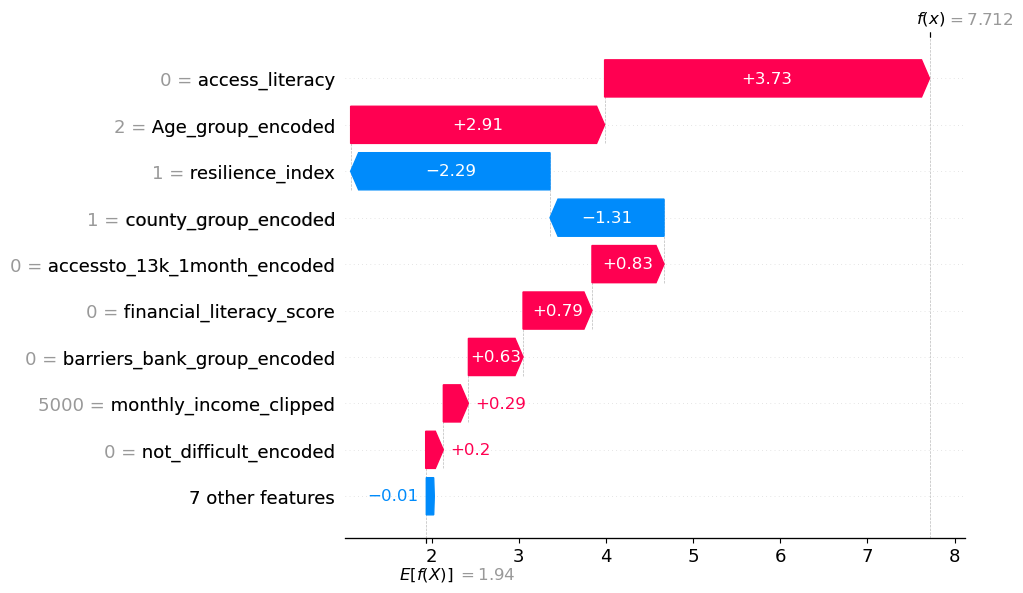

Choose an the instance(index) you want to evaluate range(0 - 2075)
If want to exit type exit:  100


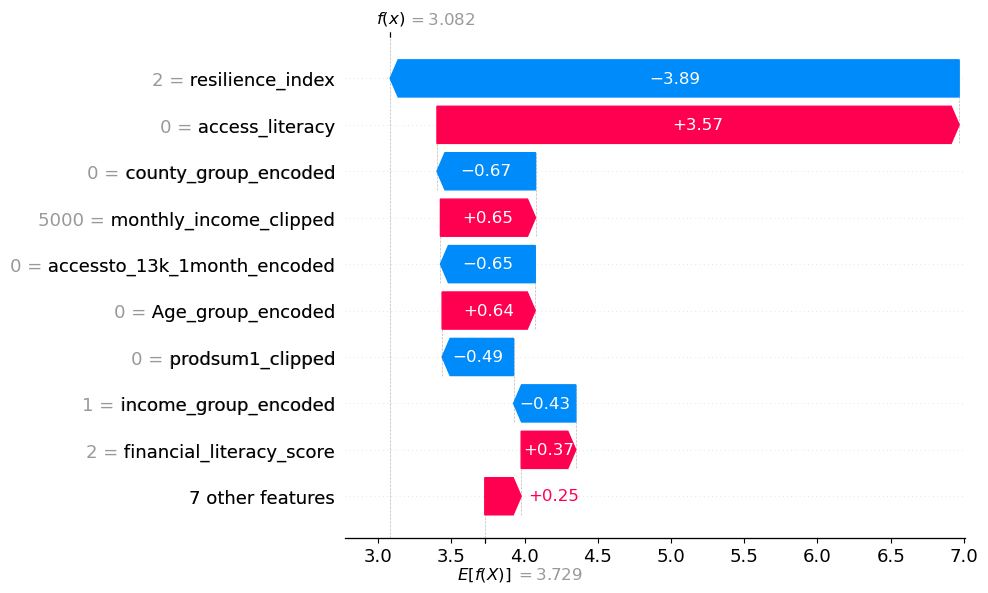

Choose an the instance(index) you want to evaluate range(0 - 2075)
If want to exit type exit:  exit


In [308]:
while True:
    # choose an index range 0 - len(X_test) - 1 = 1663
    index_to_analyse = input(f'Choose an the instance(index) you want to evaluate range(0 - {len(X_test)-1})\nIf want to exit type exit: ')
    if index_to_analyse.lower().strip() == 'exit':
        break
    index_to_analyse = int(index_to_analyse)
    # Getting the predicted class for the selected index
    predicted_class = model.predict(X_test)[index_to_analyse]
    # Getting why the predicted class was predicted for the selected instance
    single_explanation = shap.Explanation(
        values=shap_values.values[index_to_analyse,:,predicted_class],
        base_values=shap_values.base_values[index_to_analyse,predicted_class],
        data=shap_values.data[index_to_analyse],
        feature_names=shap_values.feature_names
    )
    # Plotting the resason - feature influence
    shap.plots.waterfall(single_explanation)
    plt.show()
    

## 10. Conclusion

#### Final Insights: Predictors of Financial Deterioration (FinAccess 2024, Kenya)

### Model Performance
- **Weighted F1-Score:** 0.98  
- **Accuracy:** 98%  
- The model demonstrates **high reliability**, meaning the insights are statistically robust and suitable for policy and programmatic recommendations.

---

### Key Predictors of Financial Deterioration
From logistic regression coefficients, SHAP global importance, and supporting ANOVA and correlation tests:

- **Access to Literacy & Financial Inclusion (`access_literacy`):**  
  Highest SHAP impact across all classes and strong positive correlation with financial status (Pearson = 0.50).  
  → Limited literacy and weak inclusion sharply increase risk of deterioration.

- **Monthly Income (`monthly_income_clipped`, `income_group_encoded`):**  
  ANOVA p = 0.0 confirms significant mean differences between classes.  
  Correlation (Pearson = 0.53) shows income stability directly influences financial wellbeing.  
  → Income is a decisive factor in predicting deterioration.

- **Financial Literacy Score (`financial_literacy_score`):**  
  ANOVA p = 0.0 and high correlation (Pearson = 0.56) indicate strong predictive power.  
  → Higher literacy improves resilience and reduces vulnerability.

- **Age Group (`Age_group_encoded`):**  
  Negative correlation (Pearson = −0.54) suggests older adults are more prone to deterioration.  
  → Younger and middle-aged adults show stronger recovery potential.

- **Resilience Index (`resilience_index`):**  
  Moderate positive correlation (Pearson = 0.48) and high SHAP importance.  
  → Households with higher resilience (literacy + inclusion + shock preparedness) are less likely to deteriorate.

- **County Group (`county_group_encoded`):**  
  Strong regional correlation (Pearson = 0.57).  
  → Geographic disparities remain a major determinant of financial wellbeing.

- **Shock Income (`shock_income`):**  
  Positive SHAP contribution for Class 0 and moderate correlation (Pearson = 0.23).  
  → Financial shocks without buffers increase deterioration likelihood.

---

###  Recommendations
**For Policymakers (Government & Regulators):**
- Expand **financial literacy programs** targeting vulnerable counties and older demographics.  
- Strengthen **regional equity policies** to reduce county-level disparities.  
- Invest in **shock-preparedness safety nets** (insurance, emergency funds).

**For Banks & Financial Institutions:**
- Develop **inclusive lending and savings products** tailored to low-income and vulnerable households.  
- Use **resilience-based scoring** (literacy + inclusion + shock buffers) to design risk-sensitive credit.  
- Partner with mobile money providers to expand **affordable access channels**.

**For NGOs & Development Partners:**
- Prioritize **community-level literacy and resilience training**.  
- Support **income diversification programs** to reduce vulnerability to shocks.  
- Target **women and households with disabilities** for tailored interventions.

---

### Supporting Statistical Evidence
- **ANOVA Results:**  
  - Monthly income and literacy score differ significantly across classes (p ≈ 0.0).  
  - Confirms these variables contribute meaningfully to model decisions.
- **Correlation Analysis:**  
  - Strong positive relationships between financial status and literacy (r = 0.56), income (r = 0.53), and county group (r = 0.57).  
  - Negative relationship with age (r = −0.54) highlights demographic vulnerability.

---

 *Conclusion:*  
Financial deterioration among Kenyan adults is most strongly predicted by **low literacy access, weak resilience, income instability, and regional disparities**.  
Interventions that **boost literacy, strengthen resilience, and reduce county-level inequalities** will have the greatest impact on improving financial wellbeing.
